In [2]:
!pip install hydrafloods
!pip install geopandas
import pandas as pd
import ee
import hydrafloods as hf
from hydrafloods import corrections
import seaborn as sns
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

from multiprocessing import Pool, cpu_count, Manager, Value
from tqdm import tqdm
import logging
import yaml
from functools import partial

from google.colab import drive
drive.mount('/content/drive')

# Initialize Earth Engine only once at the beginning
print("Initializing Google Earth Engine...")
ee.Authenticate()
ee.Initialize(project='ee-ageidv')  # Initialize with your project
print("Earth Engine initialized successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.2/69.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.6/86.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.3/457.3 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.9/241.9 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.6/124.6 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import logging
import os
import yaml
import ee
import pandas as pd
import time
from multiprocessing import Pool, cpu_count, Manager
from tqdm import tqdm
import sys
from datetime import datetime, date
import calendar

class TeeLogger(object):
    def __init__(self, filename):
        self.terminal = sys.stdout
        self.log = open(filename, "a", encoding='utf-8')

    def write(self, message):
        self.terminal.write(message)
        self.log.write(message)
        self.flush()

    def flush(self):
        self.terminal.flush()
        self.log.flush()

def setup_logger(log_file_path='/content/drive/MyDrive/SAR_rgl/parallel_sar_processing.log'):
    """Set up logging to both file and console."""
    logging.root.setLevel(logging.INFO)

    file_handler = logging.FileHandler(log_file_path)
    stream_handler = logging.StreamHandler(sys.stdout)

    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    file_handler.setFormatter(formatter)
    stream_handler.setFormatter(formatter)

    logger = logging.getLogger()
    logger.addHandler(file_handler)
    logger.addHandler(stream_handler)

    sys.stdout = TeeLogger(log_file_path)

    return logger

def load_config(config_path):
    print(f"Loading configuration from: {config_path}")
    with open(config_path, 'r') as config_file:
        config = yaml.safe_load(config_file)
    print("Configuration loaded successfully.")
    print(f"Configuration details: {config}")
    return config

def setup_environment(): # For JBA comparison
    print("Setting up processing environment...")

    print("Loading shapefile...")
    shapefile = ee.FeatureCollection(config['shapefile_path'])
    idname = config['id_field']
    print(f"Shapefile loaded. Using ID field: {idname}")

        # Define the bounding box we identified
    bbox = ee.Geometry.Rectangle([
        -53.7,  # minx
        -30.2,  # miny
        -52.35,  # maxx 2.7
        -29.61   # maxy 1.2
    ])

    # Filter the shapefile to include only features that intersect with the bounding box
    filtered_shapefile = shapefile.filterBounds(bbox)

    print("Getting list of polygon IDs...")
    ids = filtered_shapefile.aggregate_array(idname).getInfo()
    print(f"Number of polygons after filtering: {len(ids)}")

    print("Defining elevation datasets...")
    elv = ee.Image("JAXA/ALOS/AW3D30/V2_2").select("AVE_DSM")
    merit = ee.Image("MERIT/Hydro/v1_0_1")
    dem = merit.select("elv").unmask(0)
    hand = merit.select("hnd").unmask(0)
    print("Elevation datasets defined.")

    print("Environment setup completed.")
    return filtered_shapefile, ids, dem, hand

def fc_to_dict(fc, max_features=1000):
    """
    Convert Feature Collection to dictionary with chunking and retry logic
    """
    print("Converting Feature Collection to dictionary with chunking...")
    try:
        # Get total size of feature collection
        size = fc.size().getInfo()
        if size == 0:
            print("Empty feature collection")
            return {}

        # Get property names
        prop_names = fc.first().propertyNames().getInfo()

        # Initialize result dictionary
        result_dict = {name: [] for name in prop_names}

        # Process in chunks
        for i in range(0, size, max_features):
            chunk = fc.toList(max_features, i)

            # Add retry logic for each chunk
            max_retries = 3
            retry_count = 0
            while retry_count < max_retries:
                try:
                    chunk_fc = ee.FeatureCollection(chunk)
                    chunk_dict = chunk_fc.reduceColumns(
                        reducer=ee.Reducer.toList().repeat(len(prop_names)),
                        selectors=prop_names
                    ).getInfo()['list']

                    # Transpose the chunk results into the result dictionary
                    for j, name in enumerate(prop_names):
                        result_dict[name].extend([row[j] for row in chunk_dict])
                    break

                except ee.ee_exception.EEException as e:
                    print(f"Chunk processing failed (attempt {retry_count + 1}): {str(e)}")
                    retry_count += 1
                    if retry_count == max_retries:
                        raise
                    time.sleep(5 * retry_count)  # Exponential backoff

        return result_dict

    except Exception as e:
        print(f"Error in fc_to_dict: {str(e)}")
        return None

def process_single_polygon(args):
    """Process a single polygon for flood detection."""
    polygon_id, direction, shapefile, dem, hand, log_path, start_time, end_time = args

    # Setup worker-specific logger
    worker_logger = logging.getLogger(f'worker_{polygon_id}')
    if not worker_logger.handlers:
        fh = logging.FileHandler(log_path)
        fh.setFormatter(logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s'))
        worker_logger.addHandler(fh)
        worker_logger.setLevel(logging.INFO)

    try:
        print(f"Processing polygon ID: {polygon_id} for {direction} direction")
        worker_logger.info(f"Processing polygon ID: {polygon_id} for {direction} direction")

        # Filter shapefile for specific polygon
        region = shapefile.filterMetadata(config['id_field'], 'equals', polygon_id).first()
        if region is None:
            worker_logger.warning(f"No region found for polygon {polygon_id}")
            return None

        regiongeom = region.geometry()

        # Filter Sentinel-1 collection
        sentinel = ee.ImageCollection("COPERNICUS/S1_GRD")
        s1D = sentinel.filterBounds(regiongeom) \
            .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')) \
            .filter(ee.Filter.eq('instrumentMode', 'IW')) \
            .filterDate(start_time, end_time) \
            .filter(ee.Filter.eq('orbitProperties_pass', direction))

        img_count = s1D.size().getInfo()
        worker_logger.info(f"Found {img_count} images for polygon {polygon_id}")
        print(f"Found {img_count} images for polygon {polygon_id}")

        # Get distinct orbits
        orbits = s1D.aggregate_array('relativeOrbitNumber_start').distinct()
        orbit_list = orbits.getInfo()

        if not orbit_list:
            worker_logger.warning(f"No orbits found for polygon {polygon_id} in {direction} direction")
            return None

        # Calculate coverage for each orbit
        coverages = []
        for orbit_num in orbit_list:
            orbit_images = s1D.filterMetadata('relativeOrbitNumber_start', 'equals', orbit_num)
            first_image = orbit_images.first()

            if first_image:
                foot = ee.Feature(ee.Geometry(first_image.get('system:footprint')).convexHull(1))
                intersection = foot.intersection(region, 1)
                coverage = intersection.area().divide(ee.Feature(region).area()).getInfo()
                coverages.append((orbit_num, coverage))

        if not coverages:
            worker_logger.warning(f"No coverage data for polygon {polygon_id}")
            return None

        # Select best orbit
        best_orbit = max(coverages, key=lambda x: x[1])
        s1D = s1D.filterMetadata('relativeOrbitNumber_start', 'equals', best_orbit[0])

        # Apply processing pipeline
        s1 = hf.Dataset.from_imgcollection(s1D)
        water = s1.pipe(
            (
                hf.lee_sigma,
                (corrections.slope_correction, dict(elevation=dem, buffer=50, model="surface")),
                (hf.fuzzy_otsu, dict(band='VH', initial_threshold=-20, scale=30))
            )
        )

        watercollection = water.collection

        # Calculate flood statistics - Fixed mapping function
        def calcflood(image):
            reduced = image.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=regiongeom,
                scale=30
            )
            # reduced = ee.Dictionary(reduced).set('timestamp', image.get('system:time_start'))
            return ee.Feature(None, reduced)

        def calcsize(image):
            reduced = image.reduceRegion(
                reducer=ee.Reducer.count(),
                geometry=regiongeom,
                scale=30
            )
            return ee.Feature(None, reduced)

        # Apply the mapping functions
        results = watercollection.map(calcflood)
        size_results = watercollection.map(calcsize)

        # Convert results to dictionaries
        flood_dict = fc_to_dict(results)
        size_dict = fc_to_dict(size_results)

        if not flood_dict or not size_dict:
            worker_logger.warning(f"No data retrieved for polygon {polygon_id}")
            return None

        flood_df = pd.DataFrame(flood_dict)
        # flood_df['timestamp'] = pd.to_numeric(flood_df['timestamp'], errors='coerce')
        # flood_df['timestamp'] = pd.to_datetime(flood_df['timestamp'], unit='ms')
        size_df = pd.DataFrame(size_dict)

        # Combine and format results
        flood_df = flood_df.rename(columns={"VH": "share"})
        flood_df['polygon'] = str(polygon_id)
        flood_df['direction'] = direction

        size_df = size_df.drop(['system:index'], axis=1, errors='ignore')
        size_df = size_df.rename(columns={"VH": "size"})

        combined = pd.concat([size_df, flood_df], axis=1)
        worker_logger.info(f"Successfully processed polygon {polygon_id}")
        return combined

    except Exception as e:
        worker_logger.error(f"Error processing polygon {polygon_id} in {direction} direction: {e}", exc_info=True)
        print(f"Error processing polygon {polygon_id} in {direction} direction: {e}")
        return None

def process_polygons_parallel(ids, direction, shapefile, dem, hand, num_workers, log_path, start_time, end_time):
    """Process polygons in parallel for a specific direction."""
    print(f"\nProcessing {len(ids)} polygons in {direction} direction")

    # Prepare arguments for parallel processing
    args_list = [(polygon_id, direction, shapefile, dem, hand, log_path, start_time, end_time) for polygon_id in ids]

    results = []
    failed_ids = []

    # Process in parallel with progress bar
    with Pool(num_workers) as pool:
        # Use imap_unordered to get results as they complete
        for result in tqdm(
            pool.imap_unordered(process_single_polygon, args_list),
            total=len(args_list),
            desc=f"Processing {direction}"
        ):
            if result is not None:
                results.append(result)
            else:
                # Since we can't directly map back to the polygon ID in imap_unordered,
                # we'll need to count failed results separately
                failed_ids.append(None)  # Placeholder for now

    # Count actual successful and failed processes
    print(f"Direction {direction}: {len(results)} successful, {len(failed_ids)} failed")
    return results, failed_ids

def generate_monthly_dates(start_date, end_date):
    """Generate list of monthly start and end dates."""
    start = pd.Timestamp(start_date)
    end = pd.Timestamp(end_date)

    date_ranges = []
    current = start

    while current <= end:
        # Get the last day of the current month
        if current.month == 12:
            last_day = current.replace(day=31)
        else:
            last_day = (current.replace(day=1) + pd.DateOffset(months=1) - pd.DateOffset(days=1))

        # If this is the last iteration and we have a specific end date
        if last_day > end:
            last_day = end

        date_ranges.append({
            'start_date': current.strftime('%Y-%m-%d'),
            'end_date': last_day.strftime('%Y-%m-%d')
        })

        # Move to first day of next month
        current = (current.replace(day=1) + pd.DateOffset(months=1))

    return date_ranges

# def process_monthly_data(config, log_path):
def process_monthly_data(start_time, end_time, log_path):
    """Process SAR data for each month with improved error handling."""
    # Update args_list creation:

    logger = setup_logger(log_path)

    try:
        # date_ranges = generate_monthly_dates(
        #     config['start_time'],
        #     config['end_time']
        # )
        date_ranges = generate_monthly_dates(
            start_time,
            end_time
        )

        logger.info(f"Processing {len(date_ranges)} months of data")
        print(f"Processing {len(date_ranges)} months of data")

        for date_range in tqdm(date_ranges, desc="Processing months"):
            try:
                # Generate month string at the start
                month_str = f"{date_range['start_date'][:7]}"  # YYYY-MM format

                # Update config with current month's dates
                # current_config = config.copy()
                # current_config['start_time'] = date_range['start_date']
                # current_config['end_time'] = date_range['end_date']
                start_time = date_range['start_date']
                end_time = date_range['end_date']


                logger.info(f"\nProcessing period: {date_range['start_date']} to {date_range['end_date']}")
                print(f"\nProcessing period: {date_range['start_date']} to {date_range['end_date']}")

                # Initialize Earth Engine
                ee.Initialize()

                # Setup environment
                shapefile, ids, dem, hand = setup_environment()

                # Set number of workers
                # num_workers = min(cpu_count(), current_config.get('max_workers', cpu_count()))
                num_workers = 8

                # Process both directions for current month
                directions = ['ASCENDING', 'DESCENDING']
                all_results = []
                all_failed_ids = []  # Track failed IDs with reasons
                processed_polygons = set()
                direction_summaries = {}

                for direction in directions:

                    direction_results = []
                    failed_in_direction = []

                    # Process polygons for current direction
                    args_list = [(polygon_id, direction, shapefile, dem, hand, log_path, start_time, end_time) for polygon_id in ids]  # Added start_time, end_time

                    with Pool(num_workers) as pool:
                        for result in tqdm(
                            pool.imap_unordered(process_single_polygon, args_list),
                            total=len(args_list),
                            desc=f"Processing {direction}"
                        ):
                            if result is not None:
                                direction_results.append(result)
                                if 'polygon' in result.columns:
                                    processed_polygons.add(str(result['polygon'].iloc[0]))
                            else:
                                # Extract polygon_id from args_list
                                failed_polygon = args_list[len(direction_results) + len(failed_in_direction)][0]
                                failed_in_direction.append({
                                    'failed_id': str(failed_polygon),
                                    'direction': direction,
                                    'period_start': date_range['start_date'],
                                    'period_end': date_range['end_date']
                                })

                    all_results.extend(direction_results)
                    all_failed_ids.extend(failed_in_direction)

                    direction_summaries[direction] = {
                        'successful': len(direction_results),
                        'failed': len(failed_in_direction)
                    }

                # Save results for current month
                if all_results:
                    final_df = pd.concat(all_results, ignore_index=True)

                    # Add timestamp columns
                    final_df['period_start'] = date_range['start_date']
                    final_df['period_end'] = date_range['end_date']

                    # Sanitize column names and handle data types
                    final_df = final_df.rename(columns=lambda x: ''.join(e for e in x if e.isalnum() or e == '_'))

                    # Ensure proper data types
                    numeric_columns = ['size', 'share']
                    string_columns = ['polygon', 'direction', 'period_start', 'period_end']

                    for col in numeric_columns:
                        if col in final_df.columns:
                            final_df[col] = pd.to_numeric(final_df[col], errors='coerce').astype('float64')

                    for col in string_columns:
                        if col in final_df.columns:
                            final_df[col] = final_df[col].astype(str)

                    final_df = final_df.dropna(axis=1, how='all')

                    # Save results
                    output_base = f"{config['output_path']}/sar_{month_str}_results_both_directions_filtered_parallel"

                    try:
                        final_df.to_stata(f"{output_base}.dta", write_index=False)
                        logger.info(f"Results saved to {output_base}.dta")
                    except Exception as e:
                        logger.error(f"Error saving to Stata format: {e}")
                        final_df.to_csv(f"{output_base}.csv", index=False)
                        logger.info(f"Results saved as CSV instead")

                # Save failed IDs for current month
                if all_failed_ids:
                    failed_df = pd.DataFrame(all_failed_ids)
                    failed_path = f"{config['output_path']}/failed_ids_{month_str}_both_directions_filtered_parallel.csv"
                    failed_df.to_csv(failed_path, index=False)
                    logger.info(f"Failed IDs saved to {failed_path}")

                # Print monthly summary
                logger.info(f"\nMonthly Summary for {month_str}:")
                logger.info("==================")
                for direction, summary in direction_summaries.items():
                    logger.info(f"\n{direction}:")
                    logger.info(f"  Successful processes: {summary['successful']}")
                    logger.info(f"  Failed processes: {summary['failed']}")

                logger.info("\nOverall Monthly Summary:")
                logger.info(f"Total polygons: {len(ids)}")
                logger.info(f"Successfully processed: {len(processed_polygons)}")
                logger.info(f"Failed: {len(all_failed_ids)}")

            except Exception as e:
                logger.error(f"Error processing month {month_str}: {e}", exc_info=True)
                print(f"Error processing month {month_str}: {e}")
                continue

    except Exception as e:
        logger.error(f"Error in monthly processing: {e}", exc_info=True)
        print(f"Error in monthly processing: {e}")

def main():
    global config
    log_path = '/content/drive/MyDrive/SAR_rgl/parallel_sar_processing.log'

    # try:
    # Load configuration
    config = load_config('/content/drive/MyDrive/SAR_rgl/config.yaml')

    # Process monthly data
    # process_monthly_data(config, log_path)
    # process_monthly_data('2016-01-01', '2016-01-31', log_path)
     # Process each month of 2016
    # year = 2021
    for year in range(2022, 2023):
      for month in range(1, 13):  # 1 to 12
          # Get the last day of the month
          last_day = calendar.monthrange(year, month)[1]

          # Format dates as strings
          start = f"{year}-{month:02d}-01"
          end = f"{year}-{month:02d}-{last_day}"

          print(f"Processing month: {start} to {end}")
          process_monthly_data(start, end, log_path)

    # except Exception as e:
    #     print(f"Error in main process: {e}")

if __name__ == "__main__":
    main()

In [ ]:
import pandas as pd
from datetime import datetime, timedelta
import calendar
import logging
import os
import yaml
import ee
import pandas as pd
import time
from multiprocessing import Pool, cpu_count, Manager
from tqdm import tqdm
import sys

class TeeLogger(object):
    def __init__(self, filename):
        self.terminal = sys.stdout
        self.log = open(filename, "a", encoding='utf-8')

    def write(self, message):
        self.terminal.write(message)
        self.log.write(message)
        self.flush()

    def flush(self):
        self.terminal.flush()
        self.log.flush()

def setup_logger(log_file_path='/home/jupyter-ageidv/aev/floods/parallel_sar_processing.log'):
    """Set up logging to both file and console."""
    logging.root.setLevel(logging.INFO)

    file_handler = logging.FileHandler(log_file_path)
    stream_handler = logging.StreamHandler(sys.stdout)

    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    file_handler.setFormatter(formatter)
    stream_handler.setFormatter(formatter)

    logger = logging.getLogger()
    logger.addHandler(file_handler)
    logger.addHandler(stream_handler)

    sys.stdout = TeeLogger(log_file_path)

    return logger

def load_config(config_path):
    print(f"Loading configuration from: {config_path}")
    with open(config_path, 'r') as config_file:
        config = yaml.safe_load(config_file)
    print("Configuration loaded successfully.")
    print(f"Configuration details: {config}")
    return config

def setup_environment(): # For JBA comparison
    print("Setting up processing environment...")

    print("Loading shapefile...")
    shapefile = ee.FeatureCollection(config['shapefile_path'])
    idname = config['id_field']
    print(f"Shapefile loaded. Using ID field: {idname}")

        # Define the bounding box we identified
    bbox = ee.Geometry.Rectangle([
        -53.7,  # minx
        -30.2,  # miny
        -52.35,  # maxx 2.7
        -29.61   # maxy 1.2
    ])

    # Filter the shapefile to include only features that intersect with the bounding box
    filtered_shapefile = shapefile.filterBounds(bbox)

    print("Getting list of polygon IDs...")
    ids = filtered_shapefile.aggregate_array(idname).getInfo()
    print(f"Number of polygons after filtering: {len(ids)}")

    print("Defining elevation datasets...")
    elv = ee.Image("JAXA/ALOS/AW3D30/V2_2").select("AVE_DSM")
    merit = ee.Image("MERIT/Hydro/v1_0_1")
    dem = merit.select("elv").unmask(0)
    hand = merit.select("hnd").unmask(0)
    print("Elevation datasets defined.")

    print("Environment setup completed.")
    return filtered_shapefile, ids, dem, hand

def fc_to_dict(fc, max_features=1000):
    """
    Convert Feature Collection to dictionary with chunking and retry logic
    """
    print("Converting Feature Collection to dictionary with chunking...")
    try:
        # Get total size of feature collection
        size = fc.size().getInfo()
        if size == 0:
            print("Empty feature collection")
            return {}

        # Get property names
        prop_names = fc.first().propertyNames().getInfo()

        # Initialize result dictionary
        result_dict = {name: [] for name in prop_names}

        # Process in chunks
        for i in range(0, size, max_features):
            chunk = fc.toList(max_features, i)

            # Add retry logic for each chunk
            max_retries = 3
            retry_count = 0
            while retry_count < max_retries:
                try:
                    chunk_fc = ee.FeatureCollection(chunk)
                    chunk_dict = chunk_fc.reduceColumns(
                        reducer=ee.Reducer.toList().repeat(len(prop_names)),
                        selectors=prop_names
                    ).getInfo()['list']

                    # Transpose the chunk results into the result dictionary
                    for j, name in enumerate(prop_names):
                        result_dict[name].extend([row[j] for row in chunk_dict])
                    break

                except ee.ee_exception.EEException as e:
                    print(f"Chunk processing failed (attempt {retry_count + 1}): {str(e)}")
                    retry_count += 1
                    if retry_count == max_retries:
                        raise
                    time.sleep(5 * retry_count)  # Exponential backoff

        return result_dict

    except Exception as e:
        print(f"Error in fc_to_dict: {str(e)}")
        return None

def process_single_polygon(args):
    """Process a single polygon for flood detection."""
    polygon_id, direction, shapefile, dem, hand, log_path = args

    # Setup worker-specific logger
    worker_logger = logging.getLogger(f'worker_{polygon_id}')
    if not worker_logger.handlers:
        fh = logging.FileHandler(log_path)
        fh.setFormatter(logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s'))
        worker_logger.addHandler(fh)
        worker_logger.setLevel(logging.INFO)

    try:
        print(f"Processing polygon ID: {polygon_id} for {direction} direction")
        worker_logger.info(f"Processing polygon ID: {polygon_id} for {direction} direction")

        # Filter shapefile for specific polygon
        region = shapefile.filterMetadata(config['id_field'], 'equals', polygon_id).first()
        if region is None:
            worker_logger.warning(f"No region found for polygon {polygon_id}")
            return None

        regiongeom = region.geometry()

        # Filter Sentinel-1 collection
        sentinel = ee.ImageCollection("COPERNICUS/S1_GRD")
        s1D = sentinel.filterBounds(regiongeom) \
            .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')) \
            .filter(ee.Filter.eq('instrumentMode', 'IW')) \
            .filterDate(config['start_time'], config['end_time']) \
            .filter(ee.Filter.eq('orbitProperties_pass', direction))

        img_count = s1D.size().getInfo()
        worker_logger.info(f"Found {img_count} images for polygon {polygon_id}")
        print(f"Found {img_count} images for polygon {polygon_id}")

        # Get distinct orbits
        orbits = s1D.aggregate_array('relativeOrbitNumber_start').distinct()
        orbit_list = orbits.getInfo()

        if not orbit_list:
            worker_logger.warning(f"No orbits found for polygon {polygon_id} in {direction} direction")
            return None

        # Calculate coverage for each orbit
        coverages = []
        for orbit_num in orbit_list:
            orbit_images = s1D.filterMetadata('relativeOrbitNumber_start', 'equals', orbit_num)
            first_image = orbit_images.first()

            if first_image:
                foot = ee.Feature(ee.Geometry(first_image.get('system:footprint')).convexHull(1))
                intersection = foot.intersection(region, 1)
                coverage = intersection.area().divide(ee.Feature(region).area()).getInfo()
                coverages.append((orbit_num, coverage))

        if not coverages:
            worker_logger.warning(f"No coverage data for polygon {polygon_id}")
            return None

        # Select best orbit
        best_orbit = max(coverages, key=lambda x: x[1])
        s1D = s1D.filterMetadata('relativeOrbitNumber_start', 'equals', best_orbit[0])

        # Apply processing pipeline
        s1 = hf.Dataset.from_imgcollection(s1D)
        water = s1.pipe(
            (
                hf.lee_sigma,
                (corrections.slope_correction, dict(elevation=dem, buffer=50, model="surface")),
                (hf.fuzzy_otsu, dict(band='VH', initial_threshold=-20, scale=30))
            )
        )

        watercollection = water.collection

        # Calculate flood statistics - Fixed mapping function
        def calcflood(image):
            reduced = image.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=regiongeom,
                scale=30
            )
            return ee.Feature(None, reduced)

        def calcsize(image):
            reduced = image.reduceRegion(
                reducer=ee.Reducer.count(),
                geometry=regiongeom,
                scale=30
            )
            return ee.Feature(None, reduced)

        # Apply the mapping functions
        results = watercollection.map(calcflood)
        size_results = watercollection.map(calcsize)

        # Convert results to dictionaries
        flood_dict = fc_to_dict(results)
        size_dict = fc_to_dict(size_results)

        if not flood_dict or not size_dict:
            worker_logger.warning(f"No data retrieved for polygon {polygon_id}")
            return None

        flood_df = pd.DataFrame(flood_dict)
        size_df = pd.DataFrame(size_dict)

        # Combine and format results
        flood_df = flood_df.rename(columns={"VH": "share"})
        flood_df['polygon'] = str(polygon_id)
        flood_df['direction'] = direction

        size_df = size_df.drop(['system:index'], axis=1, errors='ignore')
        size_df = size_df.rename(columns={"VH": "size"})

        combined = pd.concat([size_df, flood_df], axis=1)
        worker_logger.info(f"Successfully processed polygon {polygon_id}")
        return combined

    except Exception as e:
        worker_logger.error(f"Error processing polygon {polygon_id} in {direction} direction: {e}", exc_info=True)
        print(f"Error processing polygon {polygon_id} in {direction} direction: {e}")
        return None

def process_polygons_parallel(ids, direction, shapefile, dem, hand, num_workers, log_path):
    """Process polygons in parallel for a specific direction."""
    print(f"\nProcessing {len(ids)} polygons in {direction} direction")

    # Prepare arguments for parallel processing
    args_list = [(polygon_id, direction, shapefile, dem, hand, log_path) for polygon_id in ids]

    results = []
    failed_ids = []

    # Process in parallel with progress bar
    with Pool(num_workers) as pool:
        # Use imap_unordered to get results as they complete
        for result in tqdm(
            pool.imap_unordered(process_single_polygon, args_list),
            total=len(args_list),
            desc=f"Processing {direction}"
        ):
            if result is not None:
                results.append(result)
            else:
                # Since we can't directly map back to the polygon ID in imap_unordered,
                # we'll need to count failed results separately
                failed_ids.append(None)  # Placeholder for now

    # Count actual successful and failed processes
    print(f"Direction {direction}: {len(results)} successful, {len(failed_ids)} failed")
    return results, failed_ids

def generate_monthly_dates(start_date='2004-01-01', end_date='2024-08-31'):
    """Generate list of monthly start and end dates."""
    start = pd.Timestamp(start_date)
    end = pd.Timestamp(end_date)

    date_ranges = []
    current = start

    while current <= end:
        # Get the last day of the current month
        if current.month == 12:
            last_day = current.replace(day=31)
        else:
            last_day = (current.replace(day=1) + pd.DateOffset(months=1) - pd.DateOffset(days=1))

        # If this is the last iteration and we have a specific end date
        if last_day > end:
            last_day = end

        date_ranges.append({
            'start_date': current.strftime('%Y-%m-%d'),
            'end_date': last_day.strftime('%Y-%m-%d')
        })

        # Move to first day of next month
        current = (current.replace(day=1) + pd.DateOffset(months=1))

    return date_ranges

def process_monthly_data(config, log_path):
    """Process SAR data for each month in the date range."""
    logger = setup_logger(log_path)

    try:
        # Generate monthly date ranges
        date_ranges = generate_monthly_dates(
            config['start_time'],
            config['end_time']
        )

        logger.info(f"Processing {len(date_ranges)} months of data")
        print(f"Processing {len(date_ranges)} months of data")

        # Process each month
        for date_range in tqdm(date_ranges, desc="Processing months"):
            try:
                # Update config with current month's dates
                current_config = config.copy()
                current_config['start_time'] = date_range['start_date']
                current_config['end_time'] = date_range['end_date']

                logger.info(f"\nProcessing period: {date_range['start_date']} to {date_range['end_date']}")
                print(f"\nProcessing period: {date_range['start_date']} to {date_range['end_date']}")

                # Initialize Earth Engine for this batch
                # ee.Initialize()

                # Setup environment
                shapefile, ids, dem, hand = setup_environment()

                # Set number of workers
                num_workers = min(cpu_count(), current_config.get('max_workers', cpu_count()))

                # Process both directions for current month
                directions = ['ASCENDING', 'DESCENDING']
                all_results = []
                processed_polygons = set()
                direction_summaries = {}

                for direction in directions:
                    direction_results, direction_failed_ids = process_polygons_parallel(
                        ids, direction, shapefile, dem, hand, num_workers, log_path
                    )

                    # Add successful results
                    for result in direction_results:
                        all_results.append(result)
                        if 'polygon' in result.columns:
                            processed_polygons.add(str(result['polygon'].iloc[0]))

                    # Store direction summary
                    direction_summaries[direction] = {
                        'successful': len(direction_results),
                        'failed': len(direction_failed_ids)
                    }

                # Calculate failed polygons
                all_polygon_ids = set(str(pid) for pid in ids)
                failed_polygons = all_polygon_ids - processed_polygons

                # Save results for current month
                if all_results:
                    final_df = pd.concat(all_results, ignore_index=True)

                    # Add timestamp columns
                    final_df['period_start'] = date_range['start_date']
                    final_df['period_end'] = date_range['end_date']

                    # Sanitize column names
                    final_df = final_df.rename(columns=lambda x: ''.join(e for e in x if e.isalnum() or e == '_'))

                    # Ensure proper data types
                    numeric_columns = ['size', 'share']
                    string_columns = ['polygon', 'direction', 'period_start', 'period_end']

                    for col in numeric_columns:
                        if col in final_df.columns:
                            final_df[col] = pd.to_numeric(final_df[col], errors='coerce').astype('float64')

                    for col in string_columns:
                        if col in final_df.columns:
                            final_df[col] = final_df[col].astype(str)

                    # Remove any completely null columns
                    final_df = final_df.dropna(axis=1, how='all')

                    # Create output paths
                    month_str = f"{date_range['start_date'][:7]}"  # YYYY-MM format
                    output_base = f"{config['output_path']}/sar_{month_str}_results_both_directions_filtered_parallel"

                    # Save as Stata
                    stata_path = f"{output_base}.dta"
                    try:
                        final_df.to_stata(stata_path, write_index=False)
                        logger.info(f"Results saved to {stata_path}")
                        print(f"Results saved to {stata_path}")
                    except Exception as e:
                        logger.error(f"Error saving to Stata format: {e}")
                        print(f"Error saving to Stata format: {e}")

                        # Backup save as CSV
                        csv_path = f"{output_base}.csv"
                        final_df.to_csv(csv_path, index=False)
                        logger.info(f"Results saved as CSV instead at: {csv_path}")
                        print(f"Results saved as CSV instead at: {csv_path}")

                # Save failed IDs for current month
                if failed_polygons:
                    failed_df = pd.DataFrame({
                        'failed_id': list(failed_polygons),
                        'period_start': date_range['start_date'],
                        'period_end': date_range['end_date']
                    })
                    failed_path = f"{config['output_path']}/failed_ids_{month_str}_both_directions_filtered_parallel.csv"
                    failed_df.to_csv(failed_path, index=False)
                    logger.info(f"Failed IDs saved to {failed_path}")

                # Print monthly summary
                logger.info(f"\nMonthly Summary for {month_str}:")
                logger.info("==================")
                for direction, summary in direction_summaries.items():
                    logger.info(f"\n{direction}:")
                    logger.info(f"  Successful processes: {summary['successful']}")
                    logger.info(f"  Failed processes: {summary['failed']}")

                logger.info("\nOverall Monthly Summary:")
                logger.info(f"Total polygons: {len(ids)}")
                logger.info(f"Successfully processed: {len(processed_polygons)}")
                logger.info(f"Failed: {len(failed_polygons)}")

            except Exception as e:
                logger.error(f"Error processing month {month_str}: {e}", exc_info=True)
                print(f"Error processing month {month_str}: {e}")
                continue

    except Exception as e:
        logger.error(f"Error in monthly processing: {e}", exc_info=True)
        print(f"Error in monthly processing: {e}")

def main():
    global config
    log_path = '/content/drive/MyDrive/SAR_rgl/parallel_sar_processing.log'

    try:
        # Load configuration
        config = load_config('/content/drive/MyDrive/SAR_rgl/config.yaml')

        # Process monthly data
        process_monthly_data(config, log_path)

    except Exception as e:
        print(f"Error in main process: {e}")

if __name__ == "__main__":
    main()

ModuleNotFoundError: No module named 'ee'

In [ ]:
import logging
import os
import yaml
import ee
import pandas as pd
import time
from multiprocessing import Pool, cpu_count, Manager, Value
from tqdm import tqdm
import sys
class TeeLogger(object):
    def __init__(self, filename):
        self.terminal = sys.stdout
        self.log = open(filename, "a", encoding='utf-8')

    def write(self, message):
        self.terminal.write(message)
        self.log.write(message)
        self.flush()

    def flush(self):
        self.terminal.flush()
        self.log.flush()

def setup_logger(log_file_path='/content/drive/MyDrive/SAR_rgl/output/full_sar_processing.log'):
    print("Setting up enhanced logger...")

    # Set up the root logger to capture all levels
    logging.root.setLevel(logging.INFO)

    # Create a file handler
    file_handler = logging.FileHandler(log_file_path)
    file_handler.setLevel(logging.INFO)

    # Create a stream handler for console output
    stream_handler = logging.StreamHandler(sys.stdout)
    stream_handler.setLevel(logging.INFO)

    # Create a formatter and set it for both handlers
    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    file_handler.setFormatter(formatter)
    stream_handler.setFormatter(formatter)

    # Get the root logger and add both handlers
    logger = logging.getLogger()
    logger.addHandler(file_handler)
    logger.addHandler(stream_handler)

    # Redirect stdout to also write to the log file
    sys.stdout = TeeLogger(log_file_path)

    print(f"Enhanced logger set up. All output will be saved at: {log_file_path}")
    return logger

logger = setup_logger()

def load_config(config_path):
    print(f"Loading configuration from: {config_path}")
    with open(config_path, 'r') as config_file:
        config = yaml.safe_load(config_file)
    print("Configuration loaded successfully.")
    print(f"Configuration details: {config}")
    return config

config = load_config('/content/drive/MyDrive/SAR_rgl/config_cobija.yaml')

print("Initializing Google Earth Engine...")
try:
    ee.Initialize()
    print("Earth Engine initialized successfully.")
except Exception as e:
    print(f"Failed to initialize Earth Engine. Attempting to re-authenticate...")
    ee.Authenticate()
    ee.Initialize(project='ee-ageidv')
    print("Earth Engine re-authenticated and initialized successfully.")
    logger.warning(f"Had to re-authenticate and initialize Earth Engine: {e}")

def check_and_initialize_ee():
    print("Checking Earth Engine initialization status...")
    try:
        if ee.data.getAssetRoots():
            print("Earth Engine is already initialized.")
            logger.info("Earth Engine is already initialized.")
        else:
            raise ee.EEException("Earth Engine not initialized")
    except ee.EEException as e:
        print(f"Earth Engine not initialized. Re-initializing...")
        logger.warning(f"Re-initializing Earth Engine due to: {e}")
        ee.Authenticate()
        ee.Initialize(project=config['ee_project'])
        print("Earth Engine re-initialized successfully.")

def fc_to_dict(fc):
    print("Converting Feature Collection to dictionary...")
    prop_names = fc.first().propertyNames()
    prop_lists = fc.reduceColumns(
        reducer=ee.Reducer.toList().repeat(prop_names.size()),
        selectors=prop_names
    ).get('list')
    result = ee.Dictionary.fromLists(prop_names, prop_lists)

    # Get the result as a Python dictionary
    result_dict = result.getInfo()

    print("Feature Collection converted to dictionary successfully.")
    print("First 10 entries of the result:")

    # Print first 10 entries of each property
    for key, value in result_dict.items():
        print(f"{key}: {value[:10]}")

    return result_dict  # Return the Python dictionary directly


def setup_environment():
    print("Setting up processing environment...")

    print("Loading shapefile...")
    shapefile = ee.FeatureCollection(config['shapefile_path'])
    idname = config['id_field']
    print(f"Shapefile loaded. Using ID field: {idname}")

    print("Getting list of polygon IDs...")
    ids = shapefile.aggregate_array(idname).getInfo()
    print(f"Number of polygons: {len(ids)}")

    print("Defining elevation datasets...")
    elv = ee.Image("JAXA/ALOS/AW3D30/V2_2").select("AVE_DSM")
    merit = ee.Image("MERIT/Hydro/v1_0_1")
    dem = merit.select("elv").unmask(0)
    hand = merit.select("hnd").unmask(0)
    print("Elevation datasets defined.")

    print("Defining IDs based on group...")
    group = config['group']
    if group == "A":
        start_index, end_index = 0, 3000
    elif group == "B":
        start_index, end_index = 3000, 6000
    elif group == "C":
        start_index, end_index = 6000, 9000
    elif group == "D":
        start_index, end_index = 9000, 12000
    elif group == "E":
        start_index, end_index = 12000, None

    ids = ids[start_index:end_index]
    print(f"Group {group} selected. Processing IDs from {start_index} to {end_index}")

    print("Starting export task...")
    export_task = ee.batch.Export.table.toDrive(
        collection=shapefile,
        description='Export_RGS',
        fileFormat='SHP',
        folder='GEE_cobija',
        fileNamePrefix='cobija'
    )
    export_task.start()
    print('Export task started. Check Google Drive for the exported file.')
    logger.info('Export task started. Check Google Drive for the exported file.')

    print("Environment setup completed.")
    return shapefile, ids, dem, hand

def process_polygon(args):
    polygon_id, direction, config, shapefile, dem, hand = args
    print(f"Processing polygon ID: {polygon_id} with direction: {direction}")
    try:
        logger.info(f"Processing polygon ID: {polygon_id} with direction: {direction}")

        print("Filtering shapefile to get the specific polygon...")
        region = shapefile.filterMetadata(config['id_field'], 'equals', polygon_id).first()
        if region is None:
            print(f"No region found for polygon {polygon_id}")
            logger.warning(f"No region found for polygon {polygon_id}")
            return None

        regiongeom = region.geometry()
        print(f"Polygon geometry retrieved for ID {polygon_id}")

        # Introduce a delay before fetching the image collection
        time.sleep(2)

        print("Filtering Sentinel-1 image collection...")
        sentinel = ee.ImageCollection("COPERNICUS/S1_GRD")
        s1D = sentinel.filterBounds(region.geometry()) \
            .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')) \
            .filter(ee.Filter.eq('instrumentMode', 'IW')) \
            .filterDate(config['start_time'], config['end_time']) \
            .filter(ee.Filter.eq('orbitProperties_pass', direction))


        print(f"Image collection size for polygon {polygon_id}: {s1D.size().getInfo()}")
        logger.info(f"Image collection size for polygon {polygon_id}: {s1D.size().getInfo()}")

        print("Getting distinct orbits...")
        orbits = s1D.aggregate_array('relativeOrbitNumber_start').distinct()
        print(f"Number of orbits found: {len(orbits.getInfo())}")
        logger.info(f"Number of orbits found: {len(orbits.getInfo())}")

        if len(orbits.getInfo()) == 0:
            print(f"No coverage data for polygon {polygon_id}")
            logger.warning(f"No coverage data for polygon {polygon_id}")
            return None

        print("Calculating coverage for each orbit...")
        def calcCoverage(orbitNum):
            first_image = s1D.filterMetadata('relativeOrbitNumber_start', 'equals', orbitNum).first()
            if first_image is None:
                return (orbitNum, 0)
            foot = first_image.get('system:footprint')
            foot = ee.Feature(ee.Geometry(foot).convexHull(1))
            intersection = foot.intersection(region, 1)
            coverage = intersection.area().divide(ee.Feature(region).area())
            return (orbitNum, coverage)

        coverages = orbits.map(calcCoverage).getInfo()
        print(f"Coverage data for polygon {polygon_id}: {coverages}")
        logger.info(f"Coverage data for polygon {polygon_id}: {coverages}")

        if not coverages:
            print(f"No coverage data for polygon {polygon_id}")
            logger.warning(f"No coverage data for polygon {polygon_id}")
            return None

        print("Creating coverage DataFrame and selecting best orbit...")
        coveragesDf = pd.DataFrame(coverages, columns=['orbitNum', 'jaccard']).sort_values(by='jaccard', ascending=False)
        if coveragesDf.empty:
            print(f"No valid orbits for polygon {polygon_id}")
            logger.warning(f"No valid orbits for polygon {polygon_id}")
            return None

        best_coverage = coveragesDf.iloc[0]['jaccard']
        print(f"Best coverage for polygon {polygon_id}: {best_coverage}")
        s1D = s1D.filterMetadata('relativeOrbitNumber_start', 'equals', int(coveragesDf.iloc[0]['orbitNum']))

        print("Applying processing pipeline...")
        s1 = hf.Dataset.from_imgcollection(s1D)
        water = s1.pipe(
            (
                hf.lee_sigma,
                (corrections.slope_correction, dict(elevation=dem, buffer=50, model="surface")),
                (hf.fuzzy_otsu, dict(band='VH', initial_threshold=-20, scale=30))
            )
        )
        print("Processing pipeline applied successfully.")

        watercollection = water.collection

        print("Calculating flood statistics...")
        def calcflood(image):
            reduced = image.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=regiongeom,
                scale=30)
            return ee.Feature(None, reduced)

        def calcsize(image):
            reduced = image.reduceRegion(
                reducer=ee.Reducer.count(),
                geometry=regiongeom,
                scale=30)
            return ee.Feature(None, reduced)

        results = watercollection.map(calcflood)
        size = watercollection.map(calcsize)

        print("Converting results to dictionaries...")
        flood_dict = fc_to_dict(results)
        size_dict = fc_to_dict(size)

        if not flood_dict or not size_dict:
            print(f"No data for polygon {polygon_id}")
            logger.warning(f"No data for polygon {polygon_id}")
            return None

        print("Creating DataFrames from results...")
        try:
            flood_df = pd.DataFrame(flood_dict)
            size_df = pd.DataFrame(size_dict)
        except Exception as e:
            print(f"Error creating DataFrames for polygon {polygon_id}: {e}")
            logger.error(f"Error creating DataFrames for polygon {polygon_id}: {e}", exc_info=True)
            return None

        if flood_df.empty or size_df.empty:
            print(f"Empty data for polygon {polygon_id}")
            logger.warning(f"Empty data for polygon {polygon_id}")
            return None

        print("Finalizing results...")
        flood_df = flood_df.rename(columns={"VH": "share"})
        flood_df = flood_df.assign(polygon=str(polygon_id))

        size_df = size_df.drop(['system:index'], axis=1, errors='ignore')
        size_df = size_df.rename(columns={"VH": "size"})

        combined = pd.concat([size_df, flood_df], axis=1)
        print(f"Processing completed for polygon {polygon_id}")
        return combined

        time.sleep(1)

    except Exception as e:
        print(f"Failed to process polygon {polygon_id}: {e}")
        logger.error(f"Failed to process polygon {polygon_id}: {e}", exc_info=True)
        return None

def process_polygon_with_retry(polygon_id, direction, config, max_retries=3):
    print(f"Processing polygon {polygon_id} with retry mechanism...")
    retries = 0
    while retries < max_retries:
        try:
            print(f"Attempt {retries + 1} for polygon {polygon_id}")
            check_and_initialize_ee()
            result = process_polygon(polygon_id, direction, config)
            if result is not None:
                print(f"Successfully processed polygon {polygon_id}")
                return result
        except ee.EEException as e:
            print(f"EE Exception for polygon {polygon_id}: {e}")
            logger.warning(f"EE Exception for polygon {polygon_id}: {e}")
            if 'expires_in' in str(e):
                print("Token expired. Re-initializing Earth Engine...")
                check_and_initialize_ee()
            retries += 1
            print(f"Retrying in 10 seconds... (Attempt {retries + 1} of {max_retries})")
            time.sleep(10)
        except Exception as e:
            print(f"General error for polygon {polygon_id}: {e}")
            logger.error(f"General error for polygon {polygon_id}: {e}", exc_info=True)
            retries += 1
            print(f"Retrying in 10 seconds... (Attempt {retries + 1} of {max_retries})")
            time.sleep(10)
    print(f"Exceeded maximum retries for polygon {polygon_id}")
    logger.error(f"Exceeded maximum retries for polygon {polygon_id}")
    return None

def parallel_process(ids, direction, num_workers, config, shapefile, dem, hand):
    print(f"Starting parallel processing with {num_workers} workers...")
    manager = Manager()
    results = manager.list()
    progress = Value('i', 0)

    def update_progress(result):
        results.append(result)
        with progress.get_lock():
            progress.value += 1
        pbar.update(1)

    print("Creating worker pool and starting processing...")
    with Pool(num_workers) as pool:
        with tqdm(total=len(ids)) as pbar:
            args_list = [(polygon_id, direction, config, shapefile, dem, hand) for polygon_id in ids]
            for _ in pool.imap_unordered(process_polygon, args_list):
                update_progress(_)

    print("Parallel processing completed.")
    return list(results)

def sanitize_column_names(df):
    print("Sanitizing column names...")
    sanitized_df = df.rename(columns=lambda x: ''.join(e for e in x if e.isalnum() or e == '_'))
    print("Column names sanitized.")
    return sanitized_df

def main():
    print("Starting main processing function...")
    check_and_initialize_ee()
    print("Setting up environment...")
    shapefile, ids, dem, hand = setup_environment()

#     num_workers = min(cpu_count(), config['max_workers'])
#     print(f'Number of workers to be used: {num_workers}')
#     logger.info(f'Workers used: {num_workers}')

#     for direction in ['ASCENDING', 'DESCENDING']:
#         print(f"\nProcessing {direction} direction")
#         logger.info(f"Processing {direction} direction")
#         results = parallel_process(ids, direction, num_workers, config, shapefile, dem, hand)

#         print("Processing results...")
#         dflist = [res for res in results if res is not None]
#         if dflist:
#             print(f"Number of successfully processed polygons: {len(dflist)}")
#             finaldf = pd.concat(dflist, ignore_index=True)
#             finaldf = sanitize_column_names(finaldf)

#             print("Saving results...")
#             output_path = f"{config['output_path']}/sar_{config['start_time'].replace('-', '')}_{config['end_time'].replace('-', '')}_results_{direction}.dta"
#             finaldf.to_stata(output_path, write_index=False)
#             logger.info(f"Results saved to {output_path}")

#         # Process failed IDs
#         failed_ids = [id for id, res in zip(ids, results) if res is None]
#         if failed_ids:
#             faileddf = pd.DataFrame(failed_ids, columns=['failed_id'])
#             failed_path = f"{config['output_path']}/failed_ids_{config['start_time'].replace('-', '')}_{config['end_time'].replace('-', '')}_{direction}.csv"
#             faileddf.to_csv(failed_path, index=False)
#             logger.info(f"Failed IDs saved to {failed_path}")

if __name__ == "__main__":
    main()

# Load and print the shapefile info
shapefile = ee.FeatureCollection(config['shapefile_path'])
print("Number of features:", shapefile.size().getInfo())
print("Properties:", shapefile.first().propertyNames().getInfo())

# Print the first feature to see its structure
print("\nFirst feature:", shapefile.first().getInfo())

INFO:google.auth.compute_engine._metadata:Compute Engine Metadata server call to universe/universe_domain returned 404, reason: 
INFO:root:Earth Engine is already initialized.
INFO:root:Export task started. Check Google Drive for the exported file.


In [ ]:
# Plots
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt
import re

# Load the results from Stata file
path_out = '/content/drive/MyDrive/SAR_rgl/output'  # Update with your actual path
results_a_A = f'{path_out}/sar_20240101_20240531_results_ASCENDING_A.dta'
results_a_B = f'{path_out}/sar_20240101_20240531_results_ASCENDING_B.dta'
results_a_C = f'{path_out}/sar_20240101_20240531_results_ASCENDING_C.dta'
results_a_D = f'{path_out}/sar_20240101_20240531_results_ASCENDING_D.dta'
results_a_E = f'{path_out}/sar_20240101_20240531_results_ASCENDING_E.dta'
results_d_A = f'{path_out}/sar_20240101_20240531_results_DESCENDING_A.dta'
results_d_B = f'{path_out}/sar_20240101_20240531_results_DESCENDING_B.dta'
results_d_C = f'{path_out}/sar_20240101_20240531_results_DESCENDING_C.dta'
results_d_D = f'{path_out}/sar_20240101_20240531_results_DESCENDING_D.dta'
results_d_E = f'{path_out}/sar_20240101_20240531_results_DESCENDING_E.dta'
# results_C = f'{path_out}/sar_04202410_05202420_C_parallel.dta'
# results_D = f'{path_out}/sar_04202410_05202420_D_parallel.dta'
# results_E = f'{path_out}/sar_04202410_05202420_E_parallel.dta'
df_a_A = pd.read_stata(results_a_A)
df_a_B = pd.read_stata(results_a_B)
df_a_C = pd.read_stata(results_a_C)
df_a_D = pd.read_stata(results_a_D)
df_a_E = pd.read_stata(results_a_E)
df_d_A = pd.read_stata(results_d_A)
df_d_B = pd.read_stata(results_d_B)
df_d_C = pd.read_stata(results_d_C)
df_d_D = pd.read_stata(results_d_D)
df_d_E = pd.read_stata(results_d_E)
# df_E = pd.read_stata(results_E)
# df_all = pd.concat([df_a_A, df_a_B, df_a_C, df_a_D, df_a_E,
#                     df_d_A, df_d_B, df_d_C, df_d_D, df_d_E])

# # Function to extract date from 'system:index'
# def extract_date(systemindex):
#     match = re.search(r'_(\d{8}T\d{6})_', systemindex)
#     if match:
#         return pd.to_datetime(match.group(1), format='%Y%m%dT%H%M%S').date()
#     return None

# # Apply the function to create a new 'date' column
# df_all['date'] = df_all['systemindex'].apply(extract_date)
# # Ensure the 'polygon' column in results_df is of the same type as the key column in gdf
# df_all['polygon'] = df_all['polygon'].astype(str)

import os

# Load the shapefile into a GeoDataFrame
shapefile_path = os.path.join('/content/drive/MyDrive/GEE_cobija/', 'cobija.shp')
# shapefile_path = os.path.join('/content/drive/MyDrive/SAR_rgl/cobija', 'cantones_geo.shp')
gdf = gpd.read_file(shapefile_path)

# Plot the shapefile
gdf.plot()
plt.title('Cobija - shapefile')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()
# gdf['id'] = gdf['id'].astype(str)  # Replace 'region_id' with the actual ID column in your shapefile

# # Merge on the polygon ID
# merged_gdf = gdf.merge(df_all, left_on='id', right_on='polygon')
# print(merged_gdf['date'].value_counts())
# gph = merged_gdf[merged_gdf['date'] == merged_gdf['date'].min()]
# # print(merged_gdf.head())
# print(len(gph))

# # Plot the shapefile
# gdf.plot()
# plt.title('Cobija - original shapefile')
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.show()

# # Plot the GeoDataFrame
# fig, ax = plt.subplots(1, 1, figsize=(6, 6))
# merged_gdf.plot(column='share', cmap='viridis', legend=True, ax=ax)
# plt.title('Water Coverage by Region - First available date')
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.show()

# # Group by 'id' and filter for the latest date
# merged_gdf['date'] = pd.to_datetime(merged_gdf['date'])
# latest_rows = merged_gdf.loc[merged_gdf.groupby('polygon')['date'].idxmax()]
# latest_rows.reset_index(drop=True, inplace=True)
# fig, ax = plt.subplots(1, 1, figsize=(6, 6))
# latest_rows.plot(column='share', cmap='viridis', legend=True, ax=ax)
# plt.title('Water Coverage by Region - latest date by polygon')
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.savefig('/content/drive/MyDrive/SAR_rgl/output/latest_water_coverage.png')
# plt.show()

# len(latest_rows)

DataSourceError: /content/drive/MyDrive/GEE_cobija/cobija.shp: No such file or directory

In [ ]:
# failed id reprocess
config = load_config('/content/drive/MyDrive/SAR_rgl/config_reprocess.yaml')

try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    # CAMBIAR ESTA CREDENCIAL!
    ee.Initialize(project = 'ee-ageidv')

failed_d_A = f'{path_out}/failed_ids_20240101_20240531_DESCENDING_A.csv'
failed_d_B = f'{path_out}/failed_ids_20240101_20240531_DESCENDING_B.csv'
failed_d_C = f'{path_out}/failed_ids_20240101_20240531_DESCENDING_C.csv'
failed_d_D = f'{path_out}/failed_ids_20240101_20240531_DESCENDING_D.csv'
failed_d_E = f'{path_out}/failed_ids_20240101_20240531_DESCENDING_E.csv'
failed_a_A = f'{path_out}/failed_ids_20240101_20240531_ASCENDING_A.csv'
failed_a_B = f'{path_out}/failed_ids_20240101_20240531_ASCENDING_B.csv'
failed_a_C = f'{path_out}/failed_ids_20240101_20240531_ASCENDING_C.csv'
failed_a_D = f'{path_out}/failed_ids_20240101_20240531_ASCENDING_D.csv'
failed_a_E = f'{path_out}/failed_ids_20240101_20240531_ASCENDING_E.csv'
df_failed_a_A = pd.read_csv(failed_a_A)
df_failed_a_B = pd.read_csv(failed_a_B)
df_failed_a_C = pd.read_csv(failed_a_C)
df_failed_a_D = pd.read_csv(failed_a_D)
df_failed_a_E = pd.read_csv(failed_a_E)
df_failed_d_A = pd.read_csv(failed_d_A)
df_failed_d_B = pd.read_csv(failed_d_B)
df_failed_d_C = pd.read_csv(failed_d_C)
df_failed_d_D = pd.read_csv(failed_d_D)
df_failed_d_E = pd.read_csv(failed_d_E)
df_failed_all = pd.concat([df_failed_a_A, df_failed_a_B, df_failed_a_C, df_failed_a_D, df_failed_a_E,
                           df_failed_d_A, df_failed_d_B, df_failed_d_C, df_failed_d_D, df_failed_d_E])
df_failed_all.drop_duplicates(inplace=True)
# correct_ids = df_all['polygon'].drop_duplicates().tolist()
# print(len(correct_ids))
# df_failed_all = df_failed_all[~df_failed_all['failed_id'].isin(correct_ids)]
# failed_ids = df_failed_all['failed_id'].drop_duplicates().tolist()
# print(len(failed_ids))

failed_ids = df_failed_d_E['failed_id'].tolist()
def main():
    global failed_ids
    check_and_initialize_ee()
    shapefile, ids, dem, hand = setup_environment()


    num_workers = min(cpu_count(), config['max_workers'])
    logger.info(f'Workers used: {num_workers}')
    ids = failed_ids

    for direction in ['DESCENDING']:
        logger.info(f"Processing {direction} direction")
        results = parallel_process(ids, direction, num_workers, config, shapefile, dem, hand)

        # Process results
        dflist = [res for res in results if res is not None]
        if dflist:
            finaldf = pd.concat(dflist, ignore_index=True)
            finaldf = sanitize_column_names(finaldf)

            # Save results
            output_path = f"{config['output_path']}/sar_{config['start_time'].replace('-', '')}_{config['end_time'].replace('-', '')}_results_{direction}_{config['group']}_reprocessed.dta"
            finaldf.to_stata(output_path, write_index=False)
            logger.info(f"Results saved to {output_path}")

        # Process failed IDs
        failed_ids = [id for id, res in zip(failed_ids, results) if res is None]
        if failed_ids:
            faileddf = pd.DataFrame(failed_ids, columns=['failed_id'])
            failed_path = f"{config['output_path']}/failed_ids_{config['start_time'].replace('-', '')}_{config['end_time'].replace('-', '')}_{direction}_{config['group']}_reprocessed.csv"
            faileddf.to_csv(failed_path, index=False)
            logger.info(f"Failed IDs saved to {failed_path}")

if __name__ == "__main__":
    main()

INFO:google.auth.compute_engine._metadata:Compute Engine Metadata server call to universe/universe_domain returned 404, reason: 


NameError: name 'path_out' is not defined

date
2024-05-11    6863
2024-05-08    5931
2024-04-15    3939
2024-05-21    3939
2024-01-10    3927
2024-05-09    3926
2024-04-27    3926
2024-02-03    3925
2024-03-10    3925
2024-03-22    3922
2024-04-03    3919
2024-01-22    3916
2024-02-15    3916
2024-02-27    3915
2024-03-17    1628
2024-03-05    1628
2024-05-04    1628
2024-04-10    1626
2024-04-22    1623
2024-01-17    1623
2024-05-16    1621
2024-02-22    1621
2024-01-29    1621
2024-05-28    1621
2024-02-10    1621
2024-03-29    1621
2024-01-05    1621
2024-04-17    1361
2024-02-17    1361
2024-02-29    1361
2024-03-12    1361
2024-03-24    1361
2024-04-05    1361
2024-02-05    1361
2024-01-12    1361
2024-01-24    1361
2024-04-29    1361
2024-05-23    1361
2024-05-30     556
2024-02-20     221
2024-01-15     221
2024-01-03     221
2024-02-08     221
2024-01-27     221
2024-03-03     221
2024-04-20     221
2024-04-08     221
2024-03-15     221
2024-05-14     221
2024-05-02     221
2024-05-26     221
2024-03-27     221
Name: c

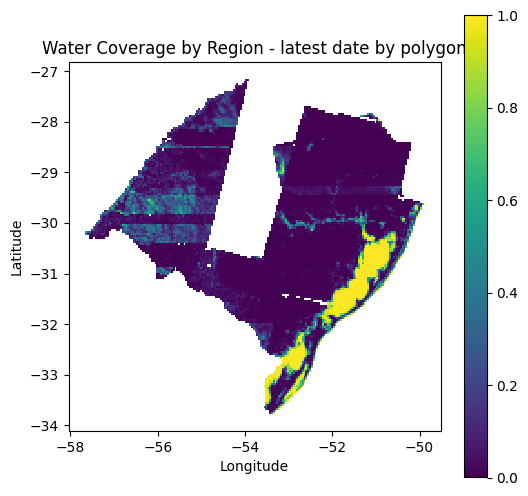

In [ ]:
# New image
reprocess_a_A = f'{path_out}/sar_20240101_20240531_results_ASCENDING_A_reprocessed.dta'
reprocess_a_B = f'{path_out}/sar_20240101_20240531_results_ASCENDING_B_reprocessed.dta'
reprocess_a_C = f'{path_out}/sar_20240101_20240531_results_ASCENDING_C_reprocessed.dta'
reprocess_a_D = f'{path_out}/sar_20240101_20240531_results_ASCENDING_D_reprocessed.dta'
reprocess_a_E = f'{path_out}/sar_20240101_20240531_results_ASCENDING_E_reprocessed.dta'
reprocess_d_A = f'{path_out}/sar_20240101_20240531_results_DESCENDING_A_reprocessed.dta'
reprocess_d_B = f'{path_out}/sar_20240101_20240531_results_DESCENDING_B_reprocessed.dta'
reprocess_d_C = f'{path_out}/sar_20240101_20240531_results_DESCENDING_C_reprocessed.dta'
reprocess_d_D = f'{path_out}/sar_20240101_20240531_results_DESCENDING_D_reprocessed.dta'
reprocess_d_E = f'{path_out}/sar_20240101_20240531_results_DESCENDING_E_reprocessed.dta'
# results_C = f'{path_out}/sar_04202410_05202420_C_parallel.dta'
# results_D = f'{path_out}/sar_04202410_05202420_D_parallel.dta'
# results_E = f'{path_out}/sar_04202410_05202420_E_parallel.dta'
re_a_A = pd.read_stata(reprocess_a_A)
re_a_B = pd.read_stata(reprocess_a_B)
re_a_C = pd.read_stata(reprocess_a_C)
re_a_D = pd.read_stata(reprocess_a_D)
re_a_E = pd.read_stata(reprocess_a_E)
re_d_A = pd.read_stata(reprocess_d_A)
re_d_B = pd.read_stata(reprocess_d_B)
re_d_C = pd.read_stata(reprocess_d_C)
re_d_D = pd.read_stata(reprocess_d_D)
re_d_E = pd.read_stata(reprocess_d_E)

re_all = pd.concat([re_a_A, re_a_B, re_a_C, re_a_D, re_a_E,
                    re_d_A, re_d_B, re_d_C, re_d_D, re_d_E])

# Apply the function to create a new 'date' column
re_all['date'] = re_all['systemindex'].apply(extract_date)
# Ensure the 'polygon' column in results_df is of the same type as the key column in gdf
re_all['polygon'] = re_all['polygon'].astype(str)

re_df_all = pd.concat([df_all, re_all])
re_df_all

# Merge on the polygon ID
merged_gdf = gdf.merge(re_df_all, left_on='id', right_on='polygon')
print(merged_gdf['date'].value_counts())
gph = merged_gdf[merged_gdf['date'] == merged_gdf['date'].min()]
# print(merged_gdf.head())
print(len(gph))

# Group by 'id' and filter for the latest date
merged_gdf['date'] = pd.to_datetime(merged_gdf['date'])
latest_rows = merged_gdf.loc[merged_gdf.groupby('polygon')['date'].idxmax()]
latest_rows.reset_index(drop=True, inplace=True)
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
latest_rows.plot(column='share', cmap='viridis', legend=True, ax=ax)
plt.title('Water Coverage by Region - latest date by polygon')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.savefig('/content/drive/MyDrive/SAR_rgl/output/latest_water_coverage.png')
plt.show()




In [ ]:
# Process for filtered locations
import logging
import os
import yaml
import ee
import pandas as pd
import time
from multiprocessing import Pool, cpu_count, Manager, Value
from tqdm import tqdm
import sys

class TeeLogger(object):
    def __init__(self, filename):
        self.terminal = sys.stdout
        self.log = open(filename, "a", encoding='utf-8')

    def write(self, message):
        self.terminal.write(message)
        self.log.write(message)
        self.flush()

    def flush(self):
        self.terminal.flush()
        self.log.flush()

def setup_logger(log_file_path='/content/drive/MyDrive/SAR_rgl/output/full_sar_processing.log'):
    print("Setting up enhanced logger...")

    # Set up the root logger to capture all levels
    logging.root.setLevel(logging.INFO)

    # Create a file handler
    file_handler = logging.FileHandler(log_file_path)
    file_handler.setLevel(logging.INFO)

    # Create a stream handler for console output
    stream_handler = logging.StreamHandler(sys.stdout)
    stream_handler.setLevel(logging.INFO)

    # Create a formatter and set it for both handlers
    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    file_handler.setFormatter(formatter)
    stream_handler.setFormatter(formatter)

    # Get the root logger and add both handlers
    logger = logging.getLogger()
    logger.addHandler(file_handler)
    logger.addHandler(stream_handler)

    # Redirect stdout to also write to the log file
    sys.stdout = TeeLogger(log_file_path)

    print(f"Enhanced logger set up. All output will be saved at: {log_file_path}")
    return logger

logger = setup_logger()

def load_config(config_path):
    print(f"Loading configuration from: {config_path}")
    with open(config_path, 'r') as config_file:
        config = yaml.safe_load(config_file)
    print("Configuration loaded successfully.")
    print(f"Configuration details: {config}")
    return config

config = load_config('/content/drive/MyDrive/SAR_rgl/config.yaml')

# print("Initializing Google Earth Engine...")
# try:
#     ee.Initialize()
#     print("Earth Engine initialized successfully.")
# except Exception as e:
#     print(f"Failed to initialize Earth Engine. Attempting to re-authenticate...")
#     ee.Authenticate()
#     ee.Initialize(project='ee-ageidv')
#     print("Earth Engine re-authenticated and initialized successfully.")
#     logger.warning(f"Had to re-authenticate and initialize Earth Engine: {e}")

# def check_and_initialize_ee():
#     print("Checking Earth Engine initialization status...")
#     try:
#         if ee.data.getAssetRoots():
#             print("Earth Engine is already initialized.")
#             logger.info("Earth Engine is already initialized.")
#         else:
#             raise ee.EEException("Earth Engine not initialized")
#     except ee.EEException as e:
#         print(f"Earth Engine not initialized. Re-initializing...")
#         logger.warning(f"Re-initializing Earth Engine due to: {e}")
#         ee.Authenticate()
#         ee.Initialize(project=config['ee_project'])
#         print("Earth Engine re-initialized successfully.")

def fc_to_dict(fc, max_features=1000):
    """
    Convert Feature Collection to dictionary with chunking and retry logic
    """
    print("Converting Feature Collection to dictionary with chunking...")
    try:
        # Get total size of feature collection
        size = fc.size().getInfo()
        if size == 0:
            print("Empty feature collection")
            return {}

        # Get property names
        prop_names = fc.first().propertyNames().getInfo()

        # Initialize result dictionary
        result_dict = {name: [] for name in prop_names}

        # Process in chunks
        for i in range(0, size, max_features):
            chunk = fc.toList(max_features, i)

            # Add retry logic for each chunk
            max_retries = 3
            retry_count = 0
            while retry_count < max_retries:
                try:
                    chunk_fc = ee.FeatureCollection(chunk)
                    chunk_dict = chunk_fc.reduceColumns(
                        reducer=ee.Reducer.toList().repeat(len(prop_names)),
                        selectors=prop_names
                    ).getInfo()['list']

                    # Transpose the chunk results into the result dictionary
                    for j, name in enumerate(prop_names):
                        result_dict[name].extend([row[j] for row in chunk_dict])
                    break

                except ee.ee_exception.EEException as e:
                    print(f"Chunk processing failed (attempt {retry_count + 1}): {str(e)}")
                    retry_count += 1
                    if retry_count == max_retries:
                        raise
                    time.sleep(5 * retry_count)  # Exponential backoff

        return result_dict

    except Exception as e:
        print(f"Error in fc_to_dict: {str(e)}")
        return None


# def setup_environment():
#     print("Setting up processing environment...")

#     print("Loading shapefile...")
#     shapefile = ee.FeatureCollection(config['shapefile_path'])
#     idname = config['id_field']
#     print(f"Shapefile loaded. Using ID field: {idname}")

#     # Define the specific locations
#     locations = [
#         ee.Geometry.Point(-51.9571292, -29.4023491),  # Neugebauer
#         ee.Geometry.Point(-51.6180628, -29.1741429),  # Tondo Alimentos Bento Gonçalves
#         ee.Geometry.Point(-51.2753086, -29.2108878)   # Tondo Alimentos Caxias do Sul
#     ]

#     # Filter the shapefile to include only features that intersect with the points
#     filtered_shapefile = shapefile.filter(ee.Filter.Or(
#         ee.Filter.intersects('.geo', locations[0]),
#         ee.Filter.intersects('.geo', locations[1]),
#         ee.Filter.intersects('.geo', locations[2])
#     ))

#     print("Getting list of polygon IDs...")
#     ids = filtered_shapefile.aggregate_array(idname).getInfo()
#     print(f"Number of polygons after filtering: {len(ids)}")

#     print("Defining elevation datasets...")
#     elv = ee.Image("JAXA/ALOS/AW3D30/V2_2").select("AVE_DSM")
#     merit = ee.Image("MERIT/Hydro/v1_0_1")
#     dem = merit.select("elv").unmask(0)
#     hand = merit.select("hnd").unmask(0)
#     print("Elevation datasets defined.")

#     print("Environment setup completed.")
#     return filtered_shapefile, ids, dem, hand

# def setup_environment(): # For factory location
#     print("Setting up processing environment...")

#     print("Loading shapefile...")
#     shapefile = ee.FeatureCollection(config['shapefile_path'])
#     idname = config['id_field']
#     print(f"Shapefile loaded. Using ID field: {idname}")

#     # Define the specific locations
#     locations = [
#         ee.Geometry.Point(-51.9571292, -29.4023491),  # Neugebauer
#         ee.Geometry.Point(-51.6180628, -29.1741429),  # Tondo Alimentos Bento Gonçalves
#         ee.Geometry.Point(-51.2753086, -29.2108878)   # Tondo Alimentos Caxias do Sul
#     ]

#     # Create buffered areas around each point
#     buffer_distance = 30000  # 10km buffer, adjust as needed
#     buffered_areas = [point.buffer(buffer_distance) for point in locations]

#     # Filter the shapefile to include features that intersect with the buffered areas
#     filtered_shapefile = shapefile.filter(ee.Filter.Or([
#         ee.Filter.intersects('.geo', buffered_area) for buffered_area in buffered_areas
#     ]))

def setup_environment(): # For JBA comparison
    print("Setting up processing environment...")

    print("Loading shapefile...")
    shapefile = ee.FeatureCollection(config['shapefile_path'])
    idname = config['id_field']
    print(f"Shapefile loaded. Using ID field: {idname}")

        # Define the bounding box we identified
    bbox = ee.Geometry.Rectangle([
        -53.7,  # minx
        -30.2,  # miny
        -52.35,  # maxx 2.7
        -29.61   # maxy 1.2
    ])

    # Filter the shapefile to include only features that intersect with the bounding box
    filtered_shapefile = shapefile.filterBounds(bbox)

    print("Getting list of polygon IDs...")
    ids = filtered_shapefile.aggregate_array(idname).getInfo()
    print(f"Number of polygons after filtering: {len(ids)}")

    print("Defining elevation datasets...")
    elv = ee.Image("JAXA/ALOS/AW3D30/V2_2").select("AVE_DSM")
    merit = ee.Image("MERIT/Hydro/v1_0_1")
    dem = merit.select("elv").unmask(0)
    hand = merit.select("hnd").unmask(0)
    print("Elevation datasets defined.")

    print("Environment setup completed.")
    return filtered_shapefile, ids, dem, hand

  # Additional filtering to ensure we get the central polygon and its neighbors
def get_neighbors(feature):
    # Get the neighbors of the feature
    neighbors = shapefile.filterBounds(feature.geometry().buffer(50))  # Small buffer to ensure adjacency
    # Include the original feature
    return neighbors.merge(ee.FeatureCollection([feature]))

    # Apply the neighbor function to each feature in the filtered shapefile
    neighbors_fc = filtered_shapefile.map(get_neighbors).flatten()

    # Remove duplicates
    final_filtered_shapefile = neighbors_fc.distinct(idname)

    print("Getting list of polygon IDs...")
    ids = final_filtered_shapefile.aggregate_array(idname).getInfo()
    print(f"Number of polygons after filtering: {len(ids)}")

    print("Defining elevation datasets...")
    elv = ee.Image("JAXA/ALOS/AW3D30/V2_2").select("AVE_DSM")
    merit = ee.Image("MERIT/Hydro/v1_0_1")
    dem = merit.select("elv").unmask(0)
    hand = merit.select("hnd").unmask(0)
    print("Elevation datasets defined.")

    print("Environment setup completed.")
    return final_filtered_shapefile, ids, dem, hand

def process_polygon(args):
    polygon_id, direction, config, shapefile, dem, hand = args
    print(f"Processing polygon ID: {polygon_id} with direction: {direction}")
    try:
        logger.info(f"Processing polygon ID: {polygon_id} with direction: {direction}")

        # Filter shapefile for specific polygon
        region = shapefile.filterMetadata(config['id_field'], 'equals', polygon_id).first()
        if region is None:
            print(f"No region found for polygon {polygon_id}")
            return None

        regiongeom = region.geometry()

        # Add a small buffer to ensure complete coverage
        regiongeom = regiongeom.buffer(30)  # 30 meters buffer

        # Optimize the Sentinel-1 filtering
        sentinel = ee.ImageCollection("COPERNICUS/S1_GRD") \
            .filterBounds(regiongeom) \
            .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')) \
            .filter(ee.Filter.eq('instrumentMode', 'IW')) \
            .filterDate(config['start_time'], config['end_time']) \
            .filter(ee.Filter.eq('orbitProperties_pass', direction))

        collection_size = sentinel.size().getInfo()
        print(f"Collection size: {collection_size}")
        if collection_size == 0:
            print(f"No images found for polygon {polygon_id}")
            return None

        # Optimize orbit selection
        orbits = sentinel.aggregate_array('relativeOrbitNumber_start').distinct().getInfo()
        if not orbits:
            return None

        # Calculate coverage more efficiently
        best_orbit = None
        best_coverage = 0
        for orbit in orbits:
            orbit_images = sentinel.filterMetadata('relativeOrbitNumber_start', 'equals', orbit)
            first_image = orbit_images.first()
            if first_image:
                coverage = ee.Feature(first_image.geometry().intersection(regiongeom, 1)) \
                    .area().divide(regiongeom.area()).getInfo()
                if coverage > best_coverage:
                    best_coverage = coverage
                    best_orbit = orbit

        if best_orbit is None:
            return None

        # Filter to best orbit
        s1D = sentinel.filterMetadata('relativeOrbitNumber_start', 'equals', best_orbit)

        # Optimize water detection
        def process_image(image):
            # Apply processing steps more efficiently
            vh = image.select('VH')
            # Apply Lee filter with smaller kernel
            vh = ee.Algorithms.Stats.leeSigma(vh, 7, 3)

            # Simplified slope correction
            terrain = ee.Terrain.slope(dem).multiply(ee.Number.pi()).divide(180.0)
            vh_corr = vh.divide(terrain.cos())

            # Water detection with fixed threshold for efficiency
            water = vh_corr.lt(-20)

            return water.set('system:time_start', image.get('system:time_start'))

        # Process images
        water_collection = ee.ImageCollection(s1D.map(process_image))

        # Calculate statistics more efficiently
        def calc_stats(image):
            stats = image.reduceRegion(
                reducer=ee.Reducer.mean().combine(ee.Reducer.count(), None, True),
                geometry=regiongeom,
                scale=30,
                maxPixels=1e9,
                bestEffort=True
            )
            return ee.Feature(None, stats)

        results = water_collection.map(calc_stats)

        # Get results with new chunking method
        flood_dict = fc_to_dict(results)
        if not flood_dict:
            return None

        # Create DataFrame
        flood_df = pd.DataFrame(flood_dict)
        flood_df['polygon'] = str(polygon_id)

        return flood_df

    except Exception as e:
        print(f"Error processing polygon {polygon_id}: {str(e)}")
        logger.error(f"Error processing polygon {polygon_id}: {str(e)}", exc_info=True)
        return None

def process_polygon_with_retry(polygon_id, direction, config, max_retries=3):
    print(f"Processing polygon {polygon_id} with retry mechanism...")
    retries = 0
    while retries < max_retries:
        try:
            print(f"Attempt {retries + 1} for polygon {polygon_id}")
            check_and_initialize_ee()
            result = process_polygon(polygon_id, direction, config)
            if result is not None:
                print(f"Successfully processed polygon {polygon_id}")
                return result
        except ee.EEException as e:
            print(f"EE Exception for polygon {polygon_id}: {e}")
            logger.warning(f"EE Exception for polygon {polygon_id}: {e}")
            if 'expires_in' in str(e):
                print("Token expired. Re-initializing Earth Engine...")
                check_and_initialize_ee()
            retries += 1
            print(f"Retrying in 10 seconds... (Attempt {retries + 1} of {max_retries})")
            time.sleep(10)
        except Exception as e:
            print(f"General error for polygon {polygon_id}: {e}")
            logger.error(f"General error for polygon {polygon_id}: {e}", exc_info=True)
            retries += 1
            print(f"Retrying in 10 seconds... (Attempt {retries + 1} of {max_retries})")
            time.sleep(10)
    print(f"Exceeded maximum retries for polygon {polygon_id}")
    logger.error(f"Exceeded maximum retries for polygon {polygon_id}")
    return None

def parallel_process(ids, direction, num_workers, config, shapefile, dem, hand):
    print(f"Starting parallel processing with {num_workers} workers...")
    manager = Manager()
    results = manager.list()
    progress = Value('i', 0)

    def update_progress(result):
        results.append(result)
        with progress.get_lock():
            progress.value += 1
        pbar.update(1)

    print("Creating worker pool and starting processing...")
    with Pool(num_workers) as pool:
        with tqdm(total=len(ids)) as pbar:
            args_list = [(polygon_id, direction, config, shapefile, dem, hand) for polygon_id in ids]
            for _ in pool.imap_unordered(process_polygon, args_list):
                update_progress(_)

    print("Parallel processing completed.")
    return list(results)

def sanitize_column_names(df):
    print("Sanitizing column names...")
    sanitized_df = df.rename(columns=lambda x: ''.join(e for e in x if e.isalnum() or e == '_'))
    print("Column names sanitized.")
    return sanitized_df

def main():
    print("Starting main processing function...")
    # check_and_initialize_ee()
    print("Setting up environment...")
    shapefile, ids, dem, hand = setup_environment()

    num_workers = min(cpu_count(), config['max_workers'])
    print(f'Number of workers to be used: {num_workers}')
    logger.info(f'Workers used: {num_workers}')

    for direction in ['DESCENDING']:
        print(f"\nProcessing {direction} direction")
        logger.info(f"Processing {direction} direction")
        results = parallel_process(ids, direction, num_workers, config, shapefile, dem, hand)

        print("Processing results...")
        dflist = [res for res in results if res is not None]
        if dflist:
            print(f"Number of successfully processed polygons: {len(dflist)}")
            finaldf = pd.concat(dflist, ignore_index=True)
            finaldf = sanitize_column_names(finaldf)

            print("Saving results...")
            output_path = f"{config['output_path']}/sar_{config['start_time'].replace('-', '')}_{config['end_time'].replace('-', '')}_results_{direction}_filtered_jba.dta"
            finaldf.to_stata(output_path, write_index=False)
            logger.info(f"Results saved to {output_path}")

        # Process failed IDs
        failed_ids = [id for id, res in zip(ids, results) if res is None]
        if failed_ids:
            faileddf = pd.DataFrame(failed_ids, columns=['failed_id'])
            failed_path = f"{config['output_path']}/failed_ids_{config['start_time'].replace('-', '')}_{config['end_time'].replace('-', '')}_{direction}_filtered_jba.csv"
            faileddf.to_csv(failed_path, index=False)
            logger.info(f"Failed IDs saved to {failed_path}")

if __name__ == "__main__":
    main()

Streaming output truncated to the last 5000 lines.
    result = computedobject.ComputedObject(self, self.promoteArgs(named_args))
  File "/usr/local/lib/python3.10/dist-packages/ee/function.py", line 103, in promoteArgs
    promoted_args[name] = Function._promoter(args[name], arg_spec['type'])
  File "/usr/local/lib/python3.10/dist-packages/ee/__init__.py", line 336, in _Promote
    return CustomFunction.create(arg, 'Object', ['Object'] * args_count)
  File "/usr/local/lib/python3.10/dist-packages/ee/customfunction.py", line 126, in create
    return CustomFunction(signature, func)
  File "/usr/local/lib/python3.10/dist-packages/ee/customfunction.py", line 40, in __init__
    if body(*variables) is None:
  File "/usr/local/lib/python3.10/dist-packages/ee/collection.py", line 666, in <lambda>
    with_cast = lambda e: algorithm(element_type(e, None))
  File "<ipython-input-6-e7f5399c19c8>", line 326, in process_image
    vh = ee.Algorithms.Stats.leeSigma(vh, 7, 3)
  File "/usr/local/lib

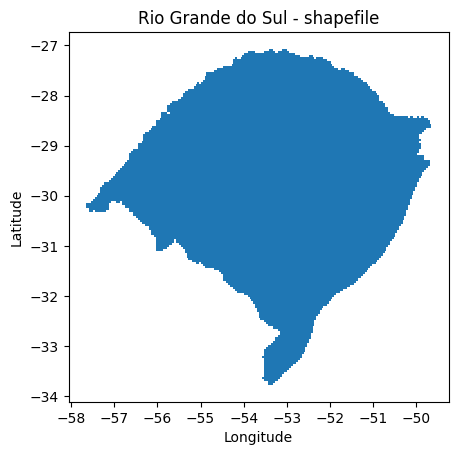

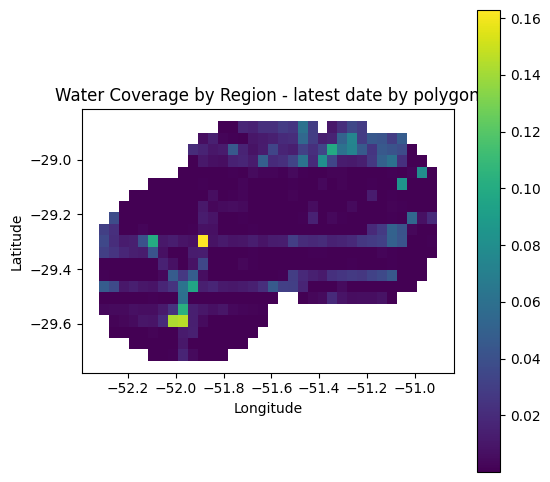

In [ ]:
# Plots
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt
import re

# Load the results from Stata file
path_out = '/content/drive/MyDrive/SAR_rgl/output'  # Update with your actual path
results_a_A = f'{path_out}/sar_20220101_20240831_results_ASCENDING_filtered.dta'
results_d_A = f'{path_out}/sar_20220101_20240831_results_DESCENDING_filtered.dta'

df_a_A = pd.read_stata(results_a_A)
df_d_A = pd.read_stata(results_d_A)

# df_E = pd.read_stata(results_E)
df_all = pd.concat([df_a_A, df_d_A])

# Function to extract date from 'system:index'
def extract_date(systemindex):
    match = re.search(r'_(\d{8}T\d{6})_', systemindex)
    if match:
        return pd.to_datetime(match.group(1), format='%Y%m%dT%H%M%S').date()
    return None

# Apply the function to create a new 'date' column
df_all['date'] = df_all['systemindex'].apply(extract_date)
# Ensure the 'polygon' column in results_df is of the same type as the key column in gdf
df_all['polygon'] = df_all['polygon'].astype(str)

import os

# Load the shapefile into a GeoDataFrame
shapefile_path = os.path.join('/content/drive/MyDrive/GEE_exports/', 'RGS.shp')
gdf = gpd.read_file(shapefile_path)

# Plot the shapefile
gdf.plot()
plt.title('Rio Grande do Sul - shapefile')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()
gdf['id'] = gdf['id'].astype(str)  # Replace 'region_id' with the actual ID column in your shapefile

# Merge on the polygon ID
merged_gdf = gdf.merge(df_all, left_on='id', right_on='polygon')
merged_gdf['date'] = pd.to_datetime(merged_gdf['date'])
latest_rows = merged_gdf.loc[merged_gdf.groupby('polygon')['date'].idxmax()]
print(merged_gdf['date'].value_counts())
gph = merged_gdf[merged_gdf['date'] == merged_gdf['date'].min()]
# print(merged_gdf.head())
print(len(gph))

# Group by 'id' and filter for the latest date
latest_rows.reset_index(drop=True, inplace=True)
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
latest_rows.plot(column='share', cmap='viridis', legend=True, ax=ax)
plt.title('Water Coverage by Region - latest date by polygon')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.savefig('/content/drive/MyDrive/SAR_rgl/output/latest_water_coverage.png')
plt.show()

len(latest_rows)

df_all['share'] = round(df_all['share']*100,3)
df_all.sort_values(by=['polygon', 'date'], ascending=True).reset_index(drop = True)
df_all.to_csv('/content/drive/MyDrive/SAR_rgl/output/df_allDirections_filtered_v2.csv', index=False)

In [ ]:
df_all['share'] = round(df_all['share']*100,3)
df_all.sort_values(by=['polygon', 'date'], ascending=True).reset_index(drop = True)

,size,share,systemindex,polygon,date
0,20742,0.2,S1A_IW_GRDH_1SDV_20230914T084916_20230914T0849...,494630,2023-09-14
1,20751,0.0,S1A_IW_GRDH_1SDV_20230926T084916_20230926T0849...,494630,2023-09-26
2,20744,0.0,S1A_IW_GRDH_1SDV_20231125T084933_20231125T0849...,494630,2023-11-25
3,13775,0.0,S1A_IW_GRDH_1SDV_20240508T220709_20240508T2207...,494630,2024-05-08
4,6966,61.0,S1A_IW_GRDH_1SDV_20240508T220734_20240508T2207...,494630,2024-05-08
...,...,...,...,...,...
241,20659,6.3,S1A_IW_GRDH_1SDV_20230926T084916_20230926T0849...,512431,2023-09-26
242,20620,6.0,S1A_IW_GRDH_1SDV_20231125T084933_20231125T0849...,512431,2023-11-25
243,20726,0.0,S1A_IW_GRDH_1SDV_20240508T220709_20240508T2207...,512431,2024-05-08
244,20661,17.7,S1A_IW_GRDH_1SDV_20240511T084914_20240511T0849...,512431,2024-05-11


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 4.1 MB/s eta 0:00:00
Before filtering: 3327
After filtering: 3199


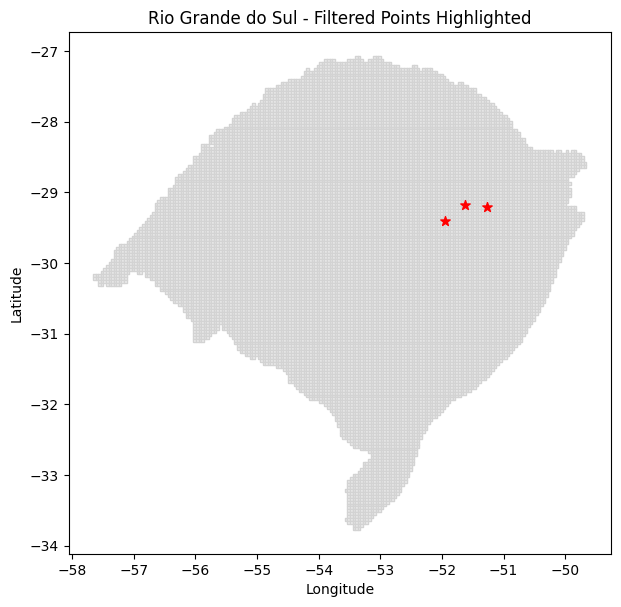

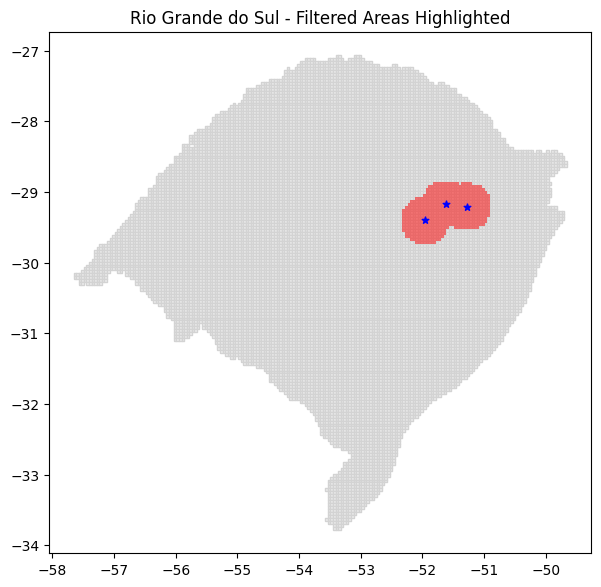

<ipython-input-2-8d1e43dcb179>:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust the layout to make room for the colorbar


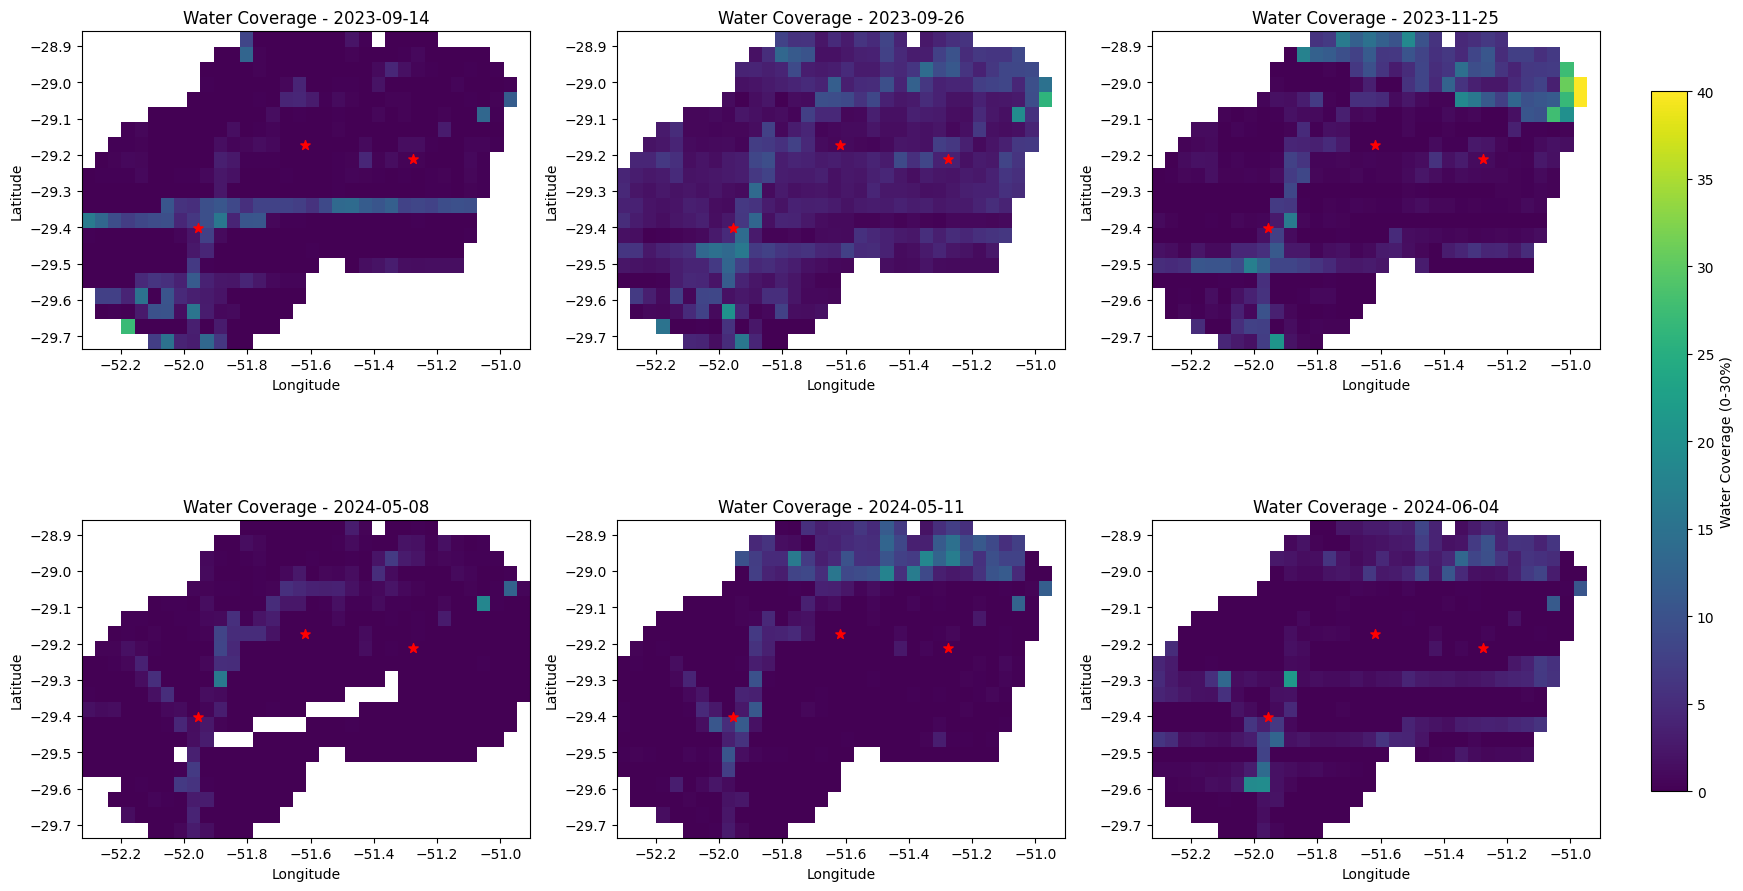

Total number of polygons: 529
Date range in data: 2023-09-09 00:00:00 to 2024-06-04 00:00:00

Data availability for specified dates:
Requested: 2023-09-14, Closest available: 2023-09-14
Requested: 2023-09-26, Closest available: 2023-09-26
Requested: 2023-11-25, Closest available: 2023-11-25
Requested: 2024-05-08, Closest available: 2024-05-08
Requested: 2024-05-11, Closest available: 2024-05-11
Requested: 2024-06-04, Closest available: 2024-06-04


In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import re
import os
from datetime import datetime
!pip install openpyxl

# Load the results from Stata file
path_out = '/content/drive/MyDrive/SAR_rgl/output'  # Update with your actual path
results_a_A = f'{path_out}/sar_20220101_20240831_results_ASCENDING_filtered.dta'
results_d_A = f'{path_out}/sar_20220101_20240831_results_DESCENDING_filtered.dta'

df_a_A = pd.read_stata(results_a_A)
df_d_A = pd.read_stata(results_d_A)

df_all = pd.concat([df_a_A, df_d_A])

# Function to extract date from 'system:index'
def extract_date(systemindex):
    match = re.search(r'_(\d{8}T\d{6})_', systemindex)
    if match:
        return pd.to_datetime(match.group(1), format='%Y%m%dT%H%M%S').date()
    return None

# Apply the function to create a new 'date' column
df_all['date'] = df_all['systemindex'].apply(extract_date)
df_all['polygon'] = df_all['polygon'].astype(str)

# Load the shapefile into a GeoDataFrame
shapefile_path = os.path.join('/content/drive/MyDrive/GEE_exports/', 'RGS.shp')
gdf = gpd.read_file(shapefile_path)
gdf['id'] = gdf['id'].astype(str)

# Merge on the polygon ID
merged_gdf = gdf.merge(df_all, left_on='id', right_on='polygon')
merged_gdf['date'] = pd.to_datetime(merged_gdf['date'])
# Filter to keep only the largest size entry for each date and polygon
print("Before filtering:", len(merged_gdf))
merged_gdf = merged_gdf.sort_values('size', ascending=False).drop_duplicates(['date', 'polygon']).reset_index(drop=True)
print("After filtering:", len(merged_gdf))

# Define the points of interest
points_of_interest = [
    Point(-51.9571292, -29.4023491),  # Neugebauer
    Point(-51.6180628, -29.1741429),  # Tondo Alimentos Bento Gonçalves
    Point(-51.2753086, -29.2108878)   # Tondo Alimentos Caxias do Sul
]

# Create a GeoDataFrame with the points of interest
points_gdf = gpd.GeoDataFrame(geometry=points_of_interest)
points_gdf.crs = gdf.crs  # Ensure the CRS matches

# Plot 1: Entire shapefile with filtered points highlighted
fig, ax = plt.subplots(figsize=(7, 7))
gdf.plot(ax=ax, color='#F0F0F0', edgecolor='#D3D3D3')  # Very light grey fill with light grey edges
points_gdf.plot(ax=ax, color='red', markersize=50, marker='*')
ax.set_title('Rio Grande do Sul - Filtered Points Highlighted')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.savefig('/content/drive/MyDrive/SAR_rgl/output/overview_filtered_points.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Entire shapefile with filtered areas highlighted
filtered_polygons = merged_gdf['polygon'].unique()
filtered_area = gdf[gdf['id'].isin(filtered_polygons)]

fig, ax = plt.subplots(figsize=(7, 7))
gdf.plot(ax=ax, color='#F0F0F0', edgecolor='#D3D3D3')
filtered_area.plot(ax=ax, color='red', alpha=0.5)
points_gdf.plot(ax=ax, color='blue', markersize=25, marker='*')
ax.set_title('Rio Grande do Sul - Filtered Areas Highlighted')
plt.savefig('/content/drive/MyDrive/SAR_rgl/output/overview_filtered_areas.png', dpi=300, bbox_inches='tight')
plt.show()

# Define 6 dates for the panels (replace these with your desired dates)
dates = [
    datetime(2023, 9, 14),
    datetime(2023, 9, 26),
    datetime(2023, 11, 25),
    datetime(2024, 5, 8),
    datetime(2024, 5, 11),
    datetime(2024, 6, 4)
]

# Create a 2x3 grid of subplots with adjusted figure size
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # Flatten the 2D array of axes for easier indexing

# Plot for each date
for i, date in enumerate(dates):
    # Get the closest date in the data to the specified date
    closest_date = merged_gdf['date'].iloc[abs(merged_gdf['date'] - date).argsort()[:1]].iloc[0]
    data_for_date = merged_gdf[merged_gdf['date'] == closest_date]

    ax = axes[i]
    plot = data_for_date.plot(column='share', cmap='viridis', ax=ax, vmin=0, vmax=0.3, legend=False)
    points_gdf.plot(ax=ax, color='red', markersize=50, marker='*')

    ax.set_title(f'Water Coverage - {closest_date.strftime("%Y-%m-%d")}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_xlim(merged_gdf.total_bounds[0], merged_gdf.total_bounds[2])
    ax.set_ylim(merged_gdf.total_bounds[1], merged_gdf.total_bounds[3])

# Add a single colorbar for the entire figure
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=40))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Water Coverage (0-30%)')

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust the layout to make room for the colorbar
plt.savefig('/content/drive/MyDrive/SAR_rgl/output/water_coverage_6_dates_filtered.png', dpi=300, bbox_inches='tight')

plt.show()

# Print some statistics
print(f"Total number of polygons: {len(merged_gdf['polygon'].unique())}")
print(f"Date range in data: {merged_gdf['date'].min()} to {merged_gdf['date'].max()}")
print("\nData availability for specified dates:")
for date in dates:
    closest_date = merged_gdf['date'].iloc[abs(merged_gdf['date'] - date).argsort()[:1]].iloc[0]
    print(f"Requested: {date.strftime('%Y-%m-%d')}, Closest available: {closest_date.strftime('%Y-%m-%d')}")

# Save the processed data
df_all['share'] = round(df_all['share']*100, 3)
df_all = df_all.sort_values(by=['polygon', 'date'], ascending=True).reset_index(drop=True)
df_all.to_excel('/content/drive/MyDrive/SAR_rgl/output/df_allDirections_filtered_v2.xlsx', index=False)

In [ ]:
df_all['date'].value_counts()

,count
date,
2024-05-08,552
2023-11-25,526
2023-09-26,519
2023-09-14,518
2024-05-11,518
2024-06-04,499
2024-06-01,158
2023-09-09,30
2024-05-30,7


In [ ]:
import pandas as pd
import ee
import time
import os
from tqdm import tqdm
from functools import reduce
from concurrent.futures import ThreadPoolExecutor
import logging
import sys
import yaml
from typing import List, Optional, Dict, Any
import logging
import yaml
from multiprocessing import Pool, cpu_count, Manager, Value
import sys
from google.colab import auth
import glob

class TeeLogger(object):
    def __init__(self, filename):
        self.terminal = sys.stdout
        self.log = open(filename, "a", encoding='utf-8')

    def write(self, message):
        self.terminal.write(message)
        self.log.write(message)
        self.flush()

    def flush(self):
        self.terminal.flush()
        self.log.flush()

def setup_logger(log_file_path: str) -> logging.Logger:
    """Set up enhanced logging to both file and console."""
    logging.root.setLevel(logging.INFO)

    # Create handlers
    file_handler = logging.FileHandler(log_file_path)
    stream_handler = logging.StreamHandler(sys.stdout)

    # Create formatter
    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    file_handler.setFormatter(formatter)
    stream_handler.setFormatter(formatter)

    # Get logger and add handlers
    logger = logging.getLogger()
    logger.addHandler(file_handler)
    logger.addHandler(stream_handler)

    # Redirect stdout
    sys.stdout = TeeLogger(log_file_path)

    logger.info(f"Logger initialized. Output will be saved at: {log_file_path}")
    return logger

def load_config(config_path: str) -> dict:
    """Load and validate configuration from YAML file."""
    logger.info(f"Loading configuration from: {config_path}")
    with open(config_path, 'r') as config_file:
        config = yaml.safe_load(config_file)

    required_keys = ['project_id', 'output_path', 'shapefile_path', 'id_field',
                    'start_date', 'end_date', 'max_workers', 'batch_size']

    missing_keys = [key for key in required_keys if key not in config]
    if missing_keys:
        raise ValueError(f"Missing required configuration keys: {missing_keys}")

    logger.info("Configuration loaded successfully")
    return config
# This makes the logger object available globally
logger = setup_logger('/content/drive/MyDrive/SAR_rgl/output/modis_processing.log')

def authenticate_and_initialize_gee(project_id: str):
    """Authenticate and initialize Google Earth Engine specifically for Colab."""
    try:
        # Authenticate using Colab's auth
        auth.authenticate_user()

        # Initialize Earth Engine directly
        ee.Authenticate()
        ee.Initialize(project=project_id)

        logger.info("Earth Engine initialized successfully")
    except Exception as e:
        logger.error(f"Error during authentication: {e}")
        raise

def setup_earth_engine(project_id: str):
    """Initialize Earth Engine with retry mechanism."""
    max_retries = 3
    retry_delay = 10

    for attempt in range(max_retries):
        try:
            authenticate_and_initialize_gee(project_id)
            return
        except Exception as e:
            logger.warning(f"EE initialization attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            else:
                raise RuntimeError("Failed to initialize Earth Engine after multiple attempts")

def fc_to_dataframe(fc):
    """Convert Earth Engine FeatureCollection to pandas DataFrame with error handling."""
    try:
        # Get features with error handling
        features = fc.getInfo()
        if not features or 'features' not in features:
            logger.warning("No features found in FeatureCollection")
            return pd.DataFrame()

        features = features['features']
        if not features:
            logger.warning("Empty features list in FeatureCollection")
            return pd.DataFrame()

        # Extract properties
        data = []
        for feature in features:
            if 'properties' in feature and feature['properties']:
                properties = feature['properties']
                properties['index'] = feature.get('id')
                data.append(properties)

        # Create DataFrame
        if not data:
            logger.warning("No valid properties found in features")
            return pd.DataFrame()

        df = pd.DataFrame(data)
        return df

    except Exception as e:
        logger.error(f"Error converting FeatureCollection to DataFrame: {e}")
        return pd.DataFrame()

def setup_filtered_locations(shapefile_path: str, id_field: str) -> tuple:
    """Set up processing for specific filtered locations."""
    logger.info("Setting up filtered locations...")

    # Define specific locations
    locations = [
        ee.Geometry.Point(-51.9571292, -29.4023491),  # Neugebauer
        ee.Geometry.Point(-51.6180628, -29.1741429),  # Tondo Alimentos Bento Gonçalves
        ee.Geometry.Point(-51.2753086, -29.2108878)   # Tondo Alimentos Caxias do Sul
    ]

    shapefile = ee.FeatureCollection(shapefile_path)

    # Create buffered areas
    buffer_distance = 30000  # 30km buffer
    buffered_areas = [point.buffer(buffer_distance) for point in locations]

    # Filter shapefile
    filtered_shapefile = shapefile.filter(ee.Filter.Or([
        ee.Filter.intersects('.geo', buffered_area) for buffered_area in buffered_areas
    ]))

    # Get neighbors function
    def get_neighbors(feature):
        neighbors = shapefile.filterBounds(feature.geometry().buffer(50))
        return neighbors.merge(ee.FeatureCollection([feature]))

    # Apply neighbor function and remove duplicates
    neighbors_fc = filtered_shapefile.map(get_neighbors).flatten()
    final_filtered_shapefile = neighbors_fc.distinct(id_field)

    ids = final_filtered_shapefile.aggregate_array(id_field).getInfo()
    logger.info(f"Found {len(ids)} polygons after filtering")

    return final_filtered_shapefile, ids

# Original MODIS processing functions with added logging
def dfo_bands_gq(collection):
    """Rename bands in MODIS GQ collections."""
    logger.debug("Renaming MODIS GQ bands")
    return collection.select(
        ["sur_refl_b01", "sur_refl_b02", "num_observations"],
        ["red_250m", "nir_250m", "obs250"]
    )

# def dfo_bands_ga(collection):
#     """Rename bands in MODIS GA collections with updated band names."""
#     try:
#         # First try with state_1km
#         return collection.select(
#             ["sur_refl_b01", "sur_refl_b02", "sur_refl_b03", "sur_refl_b04",
#              "sur_refl_b05", "sur_refl_b06", "sur_refl_b07",
#              "state_1km", "num_observations_500m"],
#             ["red_500m", "nir_500m", "blue", "green", "band5", "band6", "swir",
#              "state_1km", "obs500"])
#     except ee.EEException:
#         # If state_1km is not available, try with QC_500m
#         try:
#             return collection.select(
#                 ["sur_refl_b01", "sur_refl_b02", "sur_refl_b03", "sur_refl_b04",
#                  "sur_refl_b05", "sur_refl_b06", "sur_refl_b07",
#                  "QC_500m", "num_observations_500m"],
#                 ["red_500m", "nir_500m", "blue", "green", "band5", "band6", "swir",
#                  "state_1km", "obs500"])
#         except ee.EEException as e:
#             logger.warning(f"Failed to select QA bands: {e}")
#             # If neither QA band is available, return without QA information
#             return collection.select(
#                 ["sur_refl_b01", "sur_refl_b02", "sur_refl_b03", "sur_refl_b04",
#                  "sur_refl_b05", "sur_refl_b06", "sur_refl_b07",
#                  "num_observations_500m"],
#                 ["red_500m", "nir_500m", "blue", "green", "band5", "band6", "swir",
#                  "obs500"])
# # Function that renames the bands in MODIS GQ (250-m) collections to readable band names
# def dfo_bands_gq(collection):
#     return collection.select(["sur_refl_b01", "sur_refl_b02", "num_observations"],
#                              ["red_250m", "nir_250m", "obs250"])


# Function that renames the bands in MODIS GA (500-m) collections to readable band names
def dfo_bands_ga(collection):
    return collection.select(["sur_refl_b01", "sur_refl_b02", "sur_refl_b03",
                              "sur_refl_b04", "sur_refl_b05", "sur_refl_b06", "sur_refl_b07",
                              "state_1km", "num_observations_500m"],
                             ["red_500m", "nir_500m", "blue", "green", "band5", "band6", "swir",
                              "state_1km", "obs500"])

# Join_collections joins the GQ & GA products base on similar time-fields.  The bands of each image are concatenated together.  The results is several bands with different resolutions!
def join_collections(img_coll1, img_coll2):
    filter_time_eq = ee.Filter.equals(leftField="system:time_start", rightField="system:time_start")
    joined = ee.Join.inner().apply(img_coll1, img_coll2, filter_time_eq)

    def image_cat(image): return ee.Image.cat(image.get("primary"), image.get("secondary"))

    return joined.map(image_cat)


# Function the collects both the GA/GQ data products of MODIS Aqua, renames the bands to readable versions, and joins the two collections into one.
def get_aqua(regiongeom, date_range):
    aqua_gq = ee.ImageCollection("MODIS/061/MYD09GQ").filterDate(date_range) \
        .filterBounds(regiongeom)
    aqua_ga = ee.ImageCollection("MODIS/061/MYD09GA").filterDate(date_range) \
        .filterBounds(regiongeom)
    return ee.ImageCollection(join_collections(dfo_bands_gq(aqua_gq),
                                               dfo_bands_ga(aqua_ga)))


# Function the collects both the GA/GQ data products of MODIS Terra, renames the bands to readable versions, and joins the two collections into one.
def get_terra(regiongeom, date_range):
    terra_gq = ee.ImageCollection("MODIS/061/MOD09GQ").filterDate(date_range) \
        .filterBounds(regiongeom)
    terra_ga = ee.ImageCollection("MODIS/061/MOD09GA").filterDate(date_range) \
        .filterBounds(regiongeom)
    return ee.ImageCollection(join_collections(dfo_bands_gq(terra_gq),
                                               dfo_bands_ga(terra_ga)))


# Pan sharpen the 500 images to the 250 resolution
def pan_sharpen(image):
    red_250m = image.select("red_250m")
    red_250m_safe = red_250m.where(red_250m.eq(0), 0.0000001)
    ratio = image.select("red_500m").divide(red_250m_safe)
    blue_ps = image.select("blue").divide(ratio)
    swir_ps = image.select("swir").divide(ratio)
    green_ps = image.select("green").divide(ratio)
    nir_500m_ps = image.select("nir_500m").divide(ratio)
    band5_ps = image.select("band5").divide(ratio)
    band6_ps = image.select("band6").divide(ratio)
    obs500_ps = image.select("obs500")
    return image.select("red_250m", "nir_250m", "obs250", "state_1km") \
        .addBands([blue_ps, green_ps, swir_ps, nir_500m_ps, band5_ps, band6_ps, obs500_ps]) \
        .set({"ratio_scale": ratio.projection().nominalScale()})


# Calculate ratio of images
def b1b2_ratio(img):
    exp = "float(b('nir_250m') + 13.5) / float(b('red_250m') + 1081.1)"
    dfo_ratio = img.expression(exp)  # Band 1/Band 2 Ratio Threshold
    return img.addBands(dfo_ratio.select([0], ["b1b2_ratio"])) \
        .copyProperties(img)


# Calculate average
def calcmean(regiongeom, image):
    mean = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=regiongeom,
        scale=250)
    return ee.Feature(None, mean)


# Calculate percentages
def calcpct(regiongeom, image):
    ptiles = image.reduceRegion(
        reducer=ee.Reducer.percentile([10, 20, 30, 40, 50, 60, 70, 80, 90]),
        geometry=regiongeom,
        scale=250)
    return ee.Feature(None, ptiles)


# Creates an image based on MODIS QA information from the "state_1km" QA band.  This function has several bands including cloudy areas, cloud shadow, and snow/ice.
# QA Band information is available at: http://modis-sr.ltdri.org/guide/MOD09_UserGuide_v1_3.pdf
# Table 16: 1-kilometer State QA Descriptions (16-bit)
# cloud_state ==> 0: "clear", 1: "cloudy", 2: "mixed", 3: "not set"
# cloud_shadow ==> 0: "no", 1: "yes"
# ice_flag ==> 0: "no", 1: "yes"
# snow_flag ==> 0: "no snow", 1: "snow"
def get_qa_bits(image, start, end, new_name):
    # Compute the bits we need to extract.
    pattern = 0
    for i in range(start, end + 1):
        pattern += pow(2, i)
    return image.select([0], [new_name]).bitwiseAnd(pattern).rightShift(start)

def add_qa_bands(img):
    """Modified QA band addition with graceful fallback."""
    try:
        # Try to select state_1km band
        qa_band = img.select("state_1km")

        # Process QA bits if band exists
        cloud_state = get_qa_bits(qa_band, 0, 1, "cloud_state")
        cloud_shadow = get_qa_bits(qa_band, 2, 2, "cloud_shadow")
        ice_flag = get_qa_bits(qa_band, 12, 12, "ice_flag")
        snow_flag = get_qa_bits(qa_band, 15, 15, "snow_flag")

        return img.addBands([cloud_state, cloud_shadow, ice_flag, snow_flag])

    except ee.EEException:
        logger.warning("QA bands not available, skipping QA processing")
        # Return original image if QA processing fails
        return img

# Calculate water based on thresholds
def water_detection(modis_collection, thresh_b1b2, thresh_b1, thresh_b7):
    def water_flag(img):
        # Apply thresholds to each ratio/ band
        b1b2_ratio = ee.Image(img.select('b1b2_ratio'))
        b1b2_sliced = b1b2_ratio.lt(ee.Image.constant(thresh_b1b2))  # Band 1/Band 2
        b1_sliced = img.select(["red_250m"], ["b1_thresh"]) \
            .lt(ee.Image.constant(2027))  # Band 1 Threshold
        b7_sliced = img.select(["swir"], ["b7_thresh"]) \
            .lt(ee.Image.constant(thresh_b7))  # Band 7 Threshold

        # Add all the thresholds to one image and then sum()
        thresholds = b1b2_sliced.addBands(b1_sliced).addBands(b7_sliced)
        thresholds_count = thresholds.reduce(ee.Reducer.sum())

        # Apply water_flag threshold to final image
        water_flag = thresholds_count.gte(ee.Image.constant(3))
        return water_flag.copyProperties(img).set("system:time_start",
                                                  img.get("system:time_start"))

    # Apply the 'water_flag' function over the modis collection
    water_collection = modis_collection.map(water_flag)
    return water_collection.set({'threshold_b1b2': round(thresh_b1b2, 3),
                                 'threshold_b7': round(thresh_b7, 2),
                                 'threshold_b1': round(thresh_b1, 2)})


def fc_to_dataframe(fc):
    features = fc.getInfo()['features']

    data = []
    for feature in features:
        properties = feature['properties']
        properties['index'] = feature['id']
        data.append(properties)

    # Convert the list of properties to a DataFrame
    df = pd.DataFrame(data)
    return df

# def dfo_bands_ga(collection):
#     """Rename bands in MODIS GA collections."""
#     logger.debug("Renaming MODIS GA bands")
#     return collection.select(
#         ["sur_refl_b01", "sur_refl_b02", "sur_refl_b03", "sur_refl_b04",
#          "sur_refl_b05", "sur_refl_b06", "sur_refl_b07", "num_observations_1km"],
#         ["red_500m", "nir_500m", "blue", "green", "band5", "band6", "swir", "obs500"]
#     )

# def dfo_bands_gq(collection):
#     """Rename bands in MODIS GQ collections."""
#     logger.debug("Renaming MODIS GQ bands")
#     return collection.select(
#         ["sur_refl_b01", "sur_refl_b02", "num_observations"],
#         ["red_250m", "nir_250m", "obs250"]
#     )

def join_collections(img_coll1, img_coll2):
    """Join the GQ & GA products based on similar time-fields."""
    filter_time_eq = ee.Filter.equals(leftField="system:time_start", rightField="system:time_start")
    joined = ee.Join.inner().apply(img_coll1, img_coll2, filter_time_eq)

    def image_cat(image):
        return ee.Image.cat(image.get("primary"), image.get("secondary"))

    return joined.map(image_cat)

def get_aqua(regiongeom, date_range):
    """Get MODIS Aqua data."""
    aqua_gq = ee.ImageCollection("MODIS/061/MYD09GQ").filterDate(date_range) \
        .filterBounds(regiongeom)
    aqua_ga = ee.ImageCollection("MODIS/061/MYD09GA").filterDate(date_range) \
        .filterBounds(regiongeom)
    return ee.ImageCollection(join_collections(dfo_bands_gq(aqua_gq),
                                             dfo_bands_ga(aqua_ga)))

def get_terra(regiongeom, date_range):
    """Get MODIS Terra data."""
    terra_gq = ee.ImageCollection("MODIS/061/MOD09GQ").filterDate(date_range) \
        .filterBounds(regiongeom)
    terra_ga = ee.ImageCollection("MODIS/061/MOD09GA").filterDate(date_range) \
        .filterBounds(regiongeom)
    return ee.ImageCollection(join_collections(dfo_bands_gq(terra_gq),
                                             dfo_bands_ga(terra_ga)))

def save_batch(batch_results: list, batch_index: int, output_path: str, is_final: bool = False) -> None:
    """
    Save a batch of results to CSV file.

    Args:
        batch_results: List of DataFrames to save
        batch_index: Current batch index for filename
        output_path: Base path for output files
        is_final: Whether this is the final batch
    """
    try:
        if not batch_results:
            logger.warning("No results to save in batch")
            return

        # Combine all DataFrames in the batch
        batch_df = pd.concat(batch_results, ignore_index=True)

        # Generate filename
        if is_final:
            filename = f"{output_path}_final.csv"
        else:
            filename = f"{output_path}_batch_{batch_index}.csv"

        # Save to CSV
        batch_df.to_csv(filename,
                       mode='a',
                       header=not os.path.exists(filename),
                       index=False)

        logger.info(f"Saved batch to {filename}")

    except Exception as e:
        logger.error(f"Error saving batch: {e}")
        raise

def save_failed_ids(failed_ids: list, output_path: str) -> None:
    """
    Save failed polygon IDs to a separate file.

    Args:
        failed_ids: List of IDs that failed processing
        output_path: Base path for output files
    """
    try:
        if failed_ids:
            failed_ids_path = f"{output_path}_failed_ids.csv"
            failed_df = pd.DataFrame({'failed_id': failed_ids})
            failed_df.to_csv(failed_ids_path, index=False)
            logger.info(f"Saved {len(failed_ids)} failed IDs to {failed_ids_path}")
    except Exception as e:
        logger.error(f"Error saving failed IDs: {e}")
        raise

def cleanup_temp_files(output_path: str) -> None:
    """
    Combine all batch files into a single final file and cleanup temporary files.

    Args:
        output_path: Base path for output files
    """
    try:
        # Find all batch files
        batch_files = glob.glob(f"{output_path}_batch_*.csv")

        if not batch_files:
            logger.info("No batch files to combine")
            return

        # Read and combine all files
        all_dfs = []
        for file in batch_files:
            df = pd.read_csv(file)
            all_dfs.append(df)

        # Combine all DataFrames
        final_df = pd.concat(all_dfs, ignore_index=True)

        # Save final combined file
        final_path = f"{output_path}_complete.csv"
        final_df.to_csv(final_path, index=False)

        # Remove batch files
        for file in batch_files:
            os.remove(file)

        logger.info(f"Combined all results into {final_path}")

    except Exception as e:
        logger.error(f"Error in cleanup: {e}")
        raise

def process_polygon(polygon_id, shapefile, id_field, date_range):
    """Process a single polygon with proper dataframe creation and error handling."""
    try:
        logger.info(f'Processing polygon: {polygon_id}')
        regiongeom = shapefile.filterMetadata(id_field, 'equals', polygon_id).geometry()

        # Get MODIS images
        aqua = get_aqua(regiongeom, date_range)
        terra = get_terra(regiongeom, date_range)

        # Pan-sharpen
        terra_sharp = terra.map(pan_sharpen)
        aqua_sharp = aqua.map(pan_sharpen)

        # Add band 1 and 2 ratio
        terra_ratio = terra_sharp.map(b1b2_ratio)
        aqua_ratio = aqua_sharp.map(b1b2_ratio)

        # Apply QA Band Extract to Terra & Aqua with error handling
        try:
            terra_final = terra_ratio.map(add_qa_bands)
            aqua_final = aqua_ratio.map(add_qa_bands)
        except Exception as e:
            logger.warning(f"QA band processing failed: {e}. Continuing without QA bands.")
            terra_final = terra_ratio
            aqua_final = aqua_ratio

        # Merge the Terra and Aqua products
        modis = ee.ImageCollection(terra_final.merge(aqua_final).sort("system:time_start", True))

        # Calculate modis flooding measure with standard threshold
        thresh_b1b2 = 675
        thresh_b1 = 2027
        thresh_b7 = 675
        water = water_detection(modis, thresh_b1b2, thresh_b1, thresh_b7)

        # Calculate with lower bound threshold
        thresh_b1b2 = 540
        thresh_b1 = 1621.6
        thresh_b7 = 540
        water_lb = water_detection(modis, thresh_b1b2, thresh_b1, thresh_b7)

        # Calculate with upper bound threshold
        thresh_b1b2 = 810
        thresh_b1 = 2432.4
        thresh_b7 = 810
        water_ub = water_detection(modis, thresh_b1b2, thresh_b1, thresh_b7)

        # Calculate statistics
        logger.debug("Calculating statistics...")

        # Initialize DataFrames with error handling
        try:
            # Calculate means and percentiles
            bandmean = modis.map(lambda img: calcmean(regiongeom, img))
            bandpct = modis.map(lambda img: calcpct(regiongeom, img))
            watermean = water.map(lambda img: calcmean(regiongeom, img))
            water_lbmean = water_lb.map(lambda img: calcmean(regiongeom, img))
            water_ubmean = water_ub.map(lambda img: calcmean(regiongeom, img))

            # Convert to DataFrames
            bandmean_df = fc_to_dataframe(bandmean)
            if bandmean_df.empty:
                logger.warning(f"Empty bandmean DataFrame for polygon {polygon_id}")
                return pd.DataFrame()

            bandpct_df = fc_to_dataframe(bandpct)
            watermean_df = fc_to_dataframe(watermean)
            water_lbmean_df = fc_to_dataframe(water_lbmean)
            water_ubmean_df = fc_to_dataframe(water_ubmean)

            # Merge all DataFrames
            dfs_to_merge = [
                bandmean_df,
                bandpct_df,
                watermean_df,
                water_lbmean_df,
                water_ubmean_df
            ]

            # Check if any DataFrame is empty
            if any(df.empty for df in dfs_to_merge):
                logger.warning(f"One or more empty DataFrames for polygon {polygon_id}")
                return pd.DataFrame()

            # Merge DataFrames
            final_df = reduce(
                lambda left, right: pd.merge(left, right, on='index', how='outer'),
                dfs_to_merge
            )

            # Add polygon ID column
            final_df['polygon'] = str(polygon_id)

            logger.info(f"Successfully processed polygon {polygon_id}")
            return final_df

        except Exception as e:
            logger.error(f"Error in DataFrame creation for polygon {polygon_id}: {e}")
            return pd.DataFrame()

    except Exception as e:
        logger.error(f"Error processing polygon {polygon_id}: {e}")
        return pd.DataFrame()

def process_polygon_with_retry(polygon_id: str, date_range: ee.DateRange,
                             shapefile: ee.FeatureCollection, id_field: str) -> Optional[pd.DataFrame]:
    """Process a single polygon with retry mechanism."""
    max_retries = 3
    retry_delay = 10

    for attempt in range(max_retries):
        try:
            logger.info(f"Processing polygon {polygon_id} - Attempt {attempt + 1}")

            # Fixed: Pass all required arguments to process_polygon
            result = process_polygon(
                polygon_id=polygon_id,
                shapefile=shapefile,
                id_field=id_field,
                date_range=date_range
            )

            if result is not None and not result.empty:
                logger.info(f"Successfully processed polygon {polygon_id}")
                return result

        except ee.EEException as e:
            logger.warning(f"EE Exception for polygon {polygon_id}: {e}")
            if 'expires_in' in str(e):
                setup_earth_engine(config['project_id'])
            time.sleep(retry_delay)
        except Exception as e:
            logger.error(f"Error processing polygon {polygon_id}: {e}", exc_info=True)
            if attempt == max_retries - 1:
                return None
            time.sleep(retry_delay)

    logger.error(f"Failed to process polygon {polygon_id} after {max_retries} attempts")
    return None

def save_results(batch_results: list, output_folder: str, failed_ids: list) -> None:
    """Save results and failed IDs to files in the specified folder."""
    try:
        if not batch_results:
            logger.warning("No results to save")
            return

        # Create timestamp for filenames
        timestamp = time.strftime("%Y%m%d_%H%M%S")

        # Ensure output folder exists
        os.makedirs(output_folder, exist_ok=True)

        # Define output paths
        results_file = os.path.join(output_folder, f'modis_results_{timestamp}.csv')
        failed_ids_file = os.path.join(output_folder, f'failed_ids_{timestamp}.csv')

        # Save main results
        final_df = pd.concat(batch_results, ignore_index=True)
        final_df.to_csv(results_file, index=False)
        logger.info(f"Saved results to {results_file}")

        # Save failed IDs if any
        if failed_ids:
            pd.DataFrame({'failed_id': failed_ids}).to_csv(failed_ids_file, index=False)
            logger.info(f"Saved {len(failed_ids)} failed IDs to {failed_ids_file}")

    except Exception as e:
        logger.error(f"Error saving results: {e}")
        raise

def process_polygons_in_batches(ids: List[str], date_range: ee.DateRange,
                              shapefile: ee.FeatureCollection, config: Dict[str, Any]):
    """Process polygons and save results to the specified output folder."""
    batch_results = []
    failed_ids = []

    with ThreadPoolExecutor(max_workers=config['max_workers']) as executor:
    # with ThreadPoolExecutor(max_workers=2) as executor:
        future_to_id = {
            executor.submit(
                process_polygon_with_retry,
                polygon_id=pid,
                date_range=date_range,
                shapefile=shapefile,
                id_field=config['id_field']
            ): pid
            for pid in ids
        }

        for idx, future in enumerate(tqdm(future_to_id, total=len(ids))):
            try:
                result = future.result()
                if result is not None and not result.empty:
                    batch_results.append(result)
                else:
                    failed_ids.append(future_to_id[future])

            except Exception as e:
                logger.error(f"Error processing future for polygon {future_to_id[future]}: {e}")
                failed_ids.append(future_to_id[future])

    # Save results using the output folder from config
    if batch_results or failed_ids:
        save_results(batch_results, config['output_path'], failed_ids)

def main():
    """Main execution function with enhanced logging."""
    try:
        # Initialize logger
        logger = setup_logger('/content/drive/MyDrive/SAR_rgl/output/modis_processing.log')
        logger.info("Starting main execution...")

        # Load configuration
        logger.info("Loading configuration...")
        config = load_config('/content/drive/MyDrive/SAR_rgl/config_modis.yaml')
        logger.info(f"Configuration loaded: {config}")

        # Initialize Earth Engine
        logger.info("Setting up Earth Engine...")
        setup_earth_engine(config['project_id'])
        logger.info("Earth Engine setup completed")

        # Setup filtered locations
        logger.info("Setting up filtered locations...")
        try:
            shapefile, ids = setup_filtered_locations(config['shapefile_path'],
                                                    config['id_field'])
            logger.info(f"Found {len(ids)} locations to process")
        except Exception as e:
            logger.error(f"Error in setup_filtered_locations: {e}", exc_info=True)
            raise

        # Set up date range
        logger.info("Setting up date range...")
        try:
            date_range = ee.DateRange(ee.Date(config['start_date']),
                                    ee.Date(config['end_date']))
            logger.info(f"Date range set: {config['start_date']} to {config['end_date']}")
        except Exception as e:
            logger.error(f"Error setting up date range: {e}", exc_info=True)
            raise

        # Process polygons
        logger.info("Starting polygon processing...")
        try:
            process_polygons_in_batches(
                ids=ids,
                date_range=date_range,
                shapefile=shapefile,
                config=config
            )
        except Exception as e:
            logger.error(f"Error in process_polygons_in_batches: {e}", exc_info=True)
            raise

        logger.info("Processing completed successfully")

    except Exception as e:
        logger.error(f"Fatal error in main execution: {e}", exc_info=True)
        raise

# Now run the main function
if __name__ == "__main__":
    print("Starting main execution...")
    main()

INFO:root:Logger initialized. Output will be saved at: /content/drive/MyDrive/SAR_rgl/output/modis_processing.log
INFO:root:Logger initialized. Output will be saved at: /content/drive/MyDrive/SAR_rgl/output/modis_processing.log
INFO:root:Starting main execution...
INFO:root:Loading configuration...
INFO:root:Loading configuration from: /content/drive/MyDrive/SAR_rgl/config_modis.yaml
INFO:root:Configuration loaded successfully
INFO:root:Configuration loaded: {'project_id': 'ee-ageidv', 'output_path': '/content/drive/MyDrive/SAR_rgl/output/modis', 'ee_project': 'ee-ageidv', 'shapefile_path': 'projects/ee-devapatel3-methane/assets/riograndedosul_grid', 'id_field': 'id', 'start_date': '2022-01-01', 'end_date': '2024-08-31', 'max_workers': 15, 'batch_size': 10000}
INFO:root:Setting up Earth Engine...
INFO:root:Earth Engine initialized successfully
INFO:root:Earth Engine setup completed
INFO:root:Setting up filtered locations...
INFO:root:Setting up filtered locations...
INFO:google.auth.co

<ipython-input-6-bf4d3b53e088>:24: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


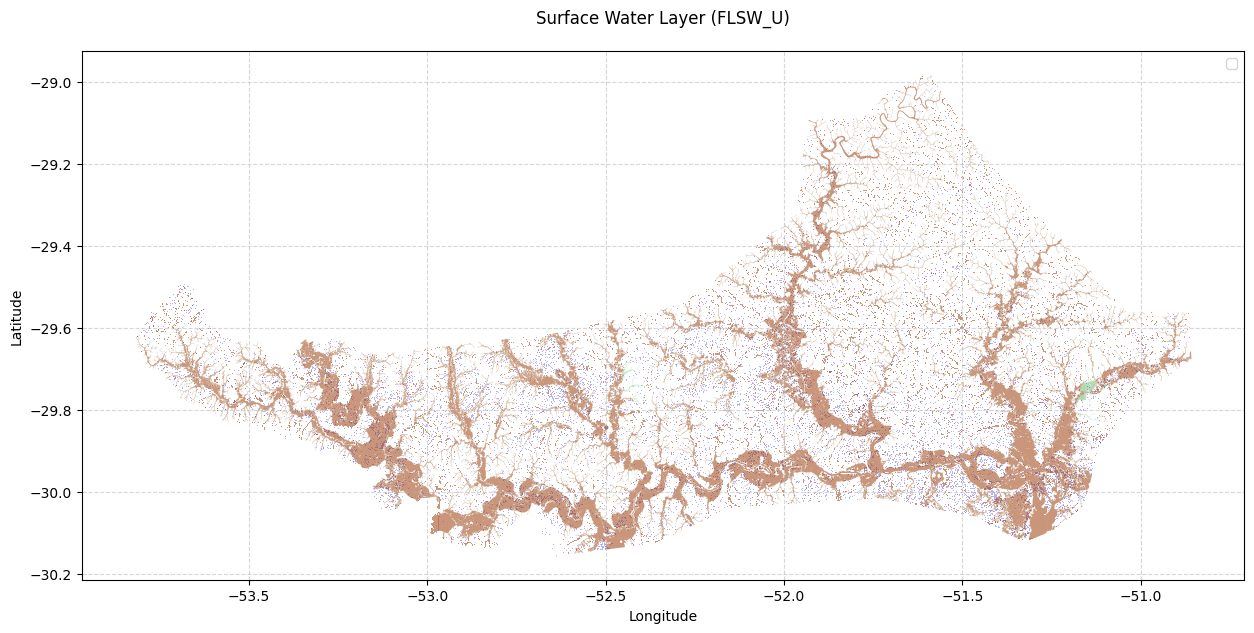

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# You only need to specify the .shp file - it will automatically read the associated files
# Read each dataset
flrf_d = gpd.read_file('/content/drive/MyDrive/SAR_rgl/jba_Brazil_Files/Vector/BR_20240502_FLRF_D_VE_30m_4326.shp')
flrf_u = gpd.read_file('/content/drive/MyDrive/SAR_rgl/jba_Brazil_Files/Vector/BR_20240502_FLRF_U_VE_30m_4326.shp')
flsw_u = gpd.read_file('/content/drive/MyDrive/SAR_rgl/jba_Brazil_Files/Vector/BR_20240502_FLSW_U_VE_30m_4326.shp')

# Create a figure and axis with a larger size
fig, ax = plt.subplots(figsize=(15, 10))

# Plot each layer with different colors and add them to legend
flsw_u.plot(ax=ax, color='blue', alpha=0.3, label='Surface Water')
flrf_u.plot(ax=ax, color='green', alpha=0.3, label='Forest Related Flooding - Updated')
flrf_d.plot(ax=ax, color='red', alpha=0.3, label='Forest Related Flooding - Detected')

# Add title and labels
plt.title('Combined Flood and Surface Water Layers', pad=20)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Add legend
plt.legend()

# Add grid
ax.grid(True, linestyle='--', alpha=0.5)

# Add some basic map elements
plt.title('Surface Water Layer (FLSW_U)', pad=20)

# Add axis labels
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Add a simple scalebar if the data is in geographic coordinates
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()